# CEO Turnover and Executive Pay Dispersion in Europe
**Data & AI in Economics | TU Dortmund**

This notebook develops an analysis-ready panel for studying whether CEO turnover changes CEO compensation and pay dispersion in European firms. It begins with the STOXX Europe 600 universe, retrieves and validates BoardEx and Compustat data, identifies firm-level CEO spells and turnover events, matches CEOs to remuneration records, and combines the resulting CEO pay panel with firm fundamentals, market capitalization, executive characteristics, sector, and country information.

> **Team size:** 2 students  
> **Deliverable:** Jupyter Notebook, extended from proposal to final analysis


<a id="toc"></a>
## Table of Contents

1. [Team](#team)
2. [Research Question](#research-question)
3. [Data Sources and Variables](#data-sources-and-variables)
4. [Setup and Helper Functions](#helper-functions)
5. [Data Collection and Profiling](#data-collection)
   - [STOXX 600 Universe](#stoxx-600-universe)
   - [BoardEx Employment Records](#boardex-employment-records)
   - [BoardEx Executive Details](#boardex-executive-details)
   - [BoardEx Remuneration Records](#boardex-remuneration-records)
   - [Compustat Fundamentals](#compustat-fundamentals)
   - [Compustat Monthly Market Prices](#compustat-market-prices)
   - [Compustat Daily Exchange Rates](#compustat-exchange-rates)
6. [CEO Turnover and Pay Panel](#ceo-turnover-and-pay-panel)
   - [CEO Turnover Events](#ceo-turnover-events)
   - [Remuneration Cleaning and EUR Conversion](#remuneration-currency-conversion)
   - [CEO Remuneration Matching](#ceo-remuneration-matching)
   - [Firm-Year CEO Pay Panel](#firm-year-ceo-pay-panel)
7. [Market Data and Market Capitalization](#market-data-and-market-capitalization)
   - [Convert Annual Fundamentals to EUR](#fundamentals-eur-conversion)
   - [Select One Exchange per Firm](#market-exchange-filter)
   - [Convert Market Prices and Construct Market Cap](#market-eur-merge)
8. [Final Analysis Panel](#final-analysis-panel)
   - [Merge Analysis Inputs](#construct-final-panel)
   - [CPI Adjustment and Real-EUR Variables](#cpi-adjustment)
9. [Data Visualizations](#data-visualizations)
   - [Target Distribution](#target-distribution)
   - [Annual Pay Trend and Coverage](#annual-pay-trend)
   - [Pay Around CEO Turnover](#turnover-event-visualization)
   - [Exploratory Relationships](#exploratory-relationships)
   - [Grouped Pay Comparisons](#grouped-pay-comparisons)
10. [Planned Methods](#planned-methods)
11. [Evaluation Strategy](#evaluation-strategy)
12. [Work Plan](#work-plan)
13. [Results and Discussion](#results-and-discussion)
   - [Causal Inference](#causal-inference-results)

**Reading guide:** run the notebook from top to bottom. The main dataset produced by the preparation workflow is `df_panel_final`; earlier tables are diagnostic checks that explain how each input contributes to that final panel.


<a id="team"></a>
## 1. Team


| Role | Name | Student ID |
|------|------|------------|
| Lead |Achmad Rizky Akbar| |
| Member | Kajetan Zduńczyk| |
| Member *(optional)* | | |


<a id="research-question"></a>
## 2. Mission Title & Research Question


**Title:** *CEO Turnover and Executive Pay Dispersion in Europe: Evidence from Leadership Changes*

**Research question:** *Does CEO turnover causally change CEO compensation levels and pay dispersion within European firms?*

**Why it matters:** *By focusing on leadership changes observed in BoardEx, we can estimate how compensation responds to a governance shock without hand‑collecting policy data. This helps investors and regulators understand whether turnover acts as a disciplining mechanism on executive pay and internal pay gaps.*

<a id="data-sources-and-variables"></a>
## 3. Data Sources and Variables


**Source(s):**  

1. **BoardEx - Individual Profile Employment**

    Includes data about Individual Profile Employment for executives in the BoardEx (Europe) universe.

    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/individual-profile/individual-profile-employment/

2. **BoardEx - Individual Profile Details**

    Includes data about Individual Profile Details for executives in the BoardEx (Europe) universe.

    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/individual-profile/individual-profile-details/

3. **Company Profile Details - BoardEx (Wharton Data Research Services)**

    Company Profile Details includes data such as location, market cap, and sector.
    
    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/company-profile/company-profile-details/

4. **Fundamentals Annual - Compustat Global (Wharton Data Research Services)**

    Provides fundamental annual company information
    
    https://wrds-www.wharton.upenn.edu/pages/get-data/compustat-capital-iq-standard-poors/compustat/global-daily/fundamentals-annual/

5. **Annual Remuneration - BoardEx (Wharton Data Research Services):**
    
    Data such as salary, bonus, and other cash compensation
    
    https://wrds-www.wharton.upenn.edu/pages/get-data/boardex/boardex-europe/compensation-analysis/annual-remuneration/

6. **Firms in Stoxx 600 Index**

    STOXX 600 is a major stock index representing the performance of 600 large-, mid-, and small-capitalization companies across 17 developed European countries.

    https://www.stoxx.com/selection-lists

**Table grains:** Employment data are role-spell records, remuneration data are executive-year records, fundamentals are firm-year records, and market prices are firm-security-month records. The final analysis table is reduced to one selected CEO observation per firm-year.

**Key variables:**

| Variable | Type | Role (feature / target / instrument / ...) | Description |
|----------|------|---------------------------------------------|-------------|
| Total CEO compensation | Numeric | **Target** | Total annual compensation retained in reported currency, nominal EUR, and real 2015 EUR |
| Pay dispersion | Numeric | **Target / Outcome** | CEO pay relative to top-executive team (e.g., CEO-to-top-5 ratio) |
| CEO turnover indicator | Binary | **Treatment** | Flag for CEO change in a given year (from BoardEx role start/end) |
| Post‑turnover period | Binary | Feature | Indicator for years after turnover (event window) |
| Firm size (log assets / market cap) | Numeric | Feature | Scale and visibility of firm |
| Profitability (ROA / EBIT margin) | Numeric | Feature | Performance controls |
| Leverage | Numeric | Feature | Capital structure |
| Industry & country fixed effects | Categorical | Feature | Sector and institutional context |

**Planned outcomes and controls:**

The preparation pipeline constructs CEO compensation and turnover variables, converts monetary levels to nominal EUR, and deflates them to country-specific real 2015 EUR. Pay dispersion remains a planned extension before the final modelling stage.

**Potential data quality issues:**  
- **Missing compensation components:** use multiple imputation or restrict to firms with complete pay breakdowns; report sensitivity to this choice.
- **Turnover date ambiguity:** define CEO change using role start/end dates and validate with overlapping roles; conduct robustness with alternative windows.
- **Reporting bias / top-coding:** winsorize extreme pay values; compare distributions by country to detect systematic reporting differences.
- **Selection bias in BoardEx coverage:** include a Stoxx 600 filter and check representativeness vs. population benchmarks.
- **Timing misalignment:** align fiscal-year fundamentals with compensation year; drop or lag inconsistent observations.
- **Currency and inflation effects:** implemented through date-aligned EUR exchange rates followed by headquarters-country CPI rebased to 2015 = 100; observations outside CPI coverage remain missing.

---

<a id="helper-functions"></a>
## 4. Setup and Helper Functions

This section defines reusable display, timing, connection, and caching utilities. Keeping these operations in one place makes the data pipeline easier to rerun and audit.


In [536]:
# Measure the running time of code blocks and print it in a readable format.

import time

def print_running_time(start_time, label="Running time"):
    """
    Print elapsed time since start_time.

    Parameters
    ----------
    start_time : float
        Start time from time.time()
    label : str
        Text label for the printed output
    """
    elapsed = time.time() - start_time

    if elapsed < 60:
        print(f"{label}: {elapsed:.2f} seconds")
    else:
        print(f"{label}: {elapsed:.2f} seconds ({elapsed / 60:.2f} minutes)")

In [537]:
import pandas as pd

# Summarizes dataset health by calculating missing values per column and total duplicate rows.
def missing_and_duplicate_summary(df, sort=True):
    """
    Show missing values breakdown per column and high-level 
    dataset text metrics including duplicate row counts.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame to inspect.
    sort : bool
        If True, sort columns by missing percentage descending.

    Returns
    -------
    pandas.DataFrame
        Table with missing counts and percentages.
    """
    # 1. Calculate general overview metrics
    total_rows = len(df)
    total_cells = df.size
    total_missing = df.isna().sum().sum()
    overall_completeness = ((total_cells - total_missing) / total_cells) * 100 if total_cells > 0 else 0
    
    # Calculate duplicate rows
    total_duplicates = df.duplicated().sum()
    duplicate_percent = (total_duplicates / total_rows) * 100 if total_rows > 0 else 0

    # 2. Print the high-level summary text
    print("==================================================")
    print("               DATA QUALITY SUMMARY               ")
    print("==================================================")
    print(f"Dataset shape       : {df.shape[0]:,} rows, {df.shape[1]:,} columns")
    print(f"Total data cells    : {total_cells:,}")
    print(f"Total missing values: {total_missing:,} ({overall_completeness:.2f}% populated)")
    print(f"Total duplicate rows: {total_duplicates:,} ({duplicate_percent:.2f}% of rows)")
    print("--------------------------------------------------\n")

    # 3. Calculate column-specific missing data
    missing_count = df.isna().sum()
    missing_percent = (missing_count / total_rows) * 100 if total_rows > 0 else 0

    missing_df = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent
    })

    missing_df["missing_percent"] = missing_df["missing_percent"].round(2)

    # 4. Filter, sort, and return
    if sort:
        missing_df = missing_df.sort_values(
            by="missing_percent",
            ascending=False
        )

    print("Detailed missing data breakdown per column:")
    return missing_df

In [538]:
# show all columns and rows in DataFrame outputs
pd.set_option('display.max_columns', None)

In [539]:
import pandas as pd
from pathlib import Path

def summarize_dataframe(df_input):
    """Display and return a dtype-safe health summary for a DataFrame or data file.

    Supports CSV, Excel, pickle, and Parquet files. Categorical statistics are
    calculated explicitly so pandas `string`, `object`, and `category` dtypes
    are handled consistently.
    """
    if isinstance(df_input, (str, Path)):
        path = Path(df_input)
        readers = {
            ".csv": pd.read_csv,
            ".xlsx": pd.read_excel,
            ".xls": pd.read_excel,
            ".pkl": pd.read_pickle,
            ".pickle": pd.read_pickle,
            ".parquet": pd.read_parquet,
        }
        if path.suffix.lower() not in readers:
            raise ValueError(
                f"Unsupported file extension: {path.suffix or '<none>'}. "
                f"Supported extensions: {sorted(readers)}"
            )
        df = readers[path.suffix.lower()](path)
        print(f"Loaded: {path}")
    elif isinstance(df_input, pd.DataFrame):
        df = df_input
    else:
        raise TypeError("df_input must be a pandas DataFrame or a supported file path.")

    if df.empty:
        print(f"Empty DataFrame with {df.shape[1]} columns.")
        return {"overview": pd.DataFrame(), "missing": pd.DataFrame()}

    try:
        duplicate_rows = int(df.duplicated().sum())
    except TypeError:
        duplicate_rows = pd.NA

    overview = pd.DataFrame({
        "value": [
            len(df),
            df.shape[1],
            duplicate_rows,
            f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB",
        ]
    }, index=["rows", "columns", "duplicate rows", "memory usage"])

    missing = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=True),
    }).sort_values(["missing_pct", "unique"], ascending=[False, False])

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = df.select_dtypes(
        include=["object", "string", "category", "bool"]
    ).columns.tolist()
    datetime_cols = df.select_dtypes(
        include=["datetime", "datetimetz"]
    ).columns.tolist()

    numeric_summary = (
        df[numeric_cols].describe().T if numeric_cols else pd.DataFrame()
    )

    categorical_rows = []
    for col in categorical_cols:
        counts = df[col].value_counts(dropna=True)
        categorical_rows.append({
            "column": col,
            "count": int(df[col].notna().sum()),
            "missing": int(df[col].isna().sum()),
            "unique": int(df[col].nunique(dropna=True)),
            "top": counts.index[0] if not counts.empty else pd.NA,
            "top_frequency": int(counts.iloc[0]) if not counts.empty else 0,
        })
    categorical_summary = (
        pd.DataFrame(categorical_rows).set_index("column")
        if categorical_rows else pd.DataFrame()
    )

    datetime_summary = pd.DataFrame()
    if datetime_cols:
        datetime_summary = pd.DataFrame({
            "min": df[datetime_cols].min(),
            "max": df[datetime_cols].max(),
            "missing": df[datetime_cols].isna().sum(),
        })

    print("### Dataset overview")
    display(overview)
    print("### Column coverage and dtypes")
    display(missing)
    if not numeric_summary.empty:
        print("### Numeric columns")
        display(numeric_summary)
    if not categorical_summary.empty:
        print("### Categorical columns")
        display(categorical_summary)
    if not datetime_summary.empty:
        print("### Datetime columns")
        display(datetime_summary)

    return {
        "overview": overview,
        "missing": missing,
        "numeric": numeric_summary,
        "categorical": categorical_summary,
        "datetime": datetime_summary,
    }


<a id="data-collection"></a>
## 5. Data Collection and Profiling

The data pipeline follows a common STOXX 600 sample frame:

1. STOXX 600 ISINs define the firm universe.
2. BoardEx employment records provide CEO roles and turnover dates.
3. BoardEx executive details provide demographic characteristics.
4. BoardEx remuneration records provide annual compensation.
5. Compustat annual fundamentals provide firm-year controls.
6. Compustat monthly security data provide prices for market capitalization.
7. Compustat daily exchange rates provide the currency bridge to EUR.

Each query selects only columns used by the preparation or modelling pipeline. This reduces WRDS transfer time, cache size, and in-memory DataFrame size while keeping identifiers needed for validation. The sources are combined only after their identifiers, dates, currencies, and table grains have been checked.


<a id="stoxx-600-universe"></a>
### 5.1 STOXX 600 Company Universe


Before querying BoardEx, we define the project sample. The analysis is restricted to firms in the STOXX Europe 600. We use the `stoxx600_clean.csv` file as the sample frame and extract its ISINs as the main identifier for WRDS queries.

In [540]:
# Core packages and project paths
import wrds
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data")
STOXX_FILE = DATA_DIR / "stoxx600_clean.csv"
WRDS_CACHE_DIR = DATA_DIR / "wrds_cache"
WRDS_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Set this to True when you deliberately want to replace all cached WRDS data.
REFRESH_WRDS_CACHE = False

def get_wrds_connection():
    """Create the WRDS connection only when a server query is actually needed."""
    global conn

    try:
        conn
        print("Using existing WRDS connection.")
    except NameError:
        conn = wrds.Connection()
        print("Created new WRDS connection.")

    return conn


def load_or_fetch(cache_name, fetch_function, refresh=False):
    """Load a DataFrame from disk, or fetch and cache it when unavailable.

    Parameters
    ----------
    cache_name : str
        File stem used inside WRDS_CACHE_DIR.
    fetch_function : callable
        Zero-argument function that retrieves and returns a DataFrame.
    refresh : bool
        If True, ignore any existing cache and retrieve fresh data.
    """
    cache_path = WRDS_CACHE_DIR / f"{cache_name}.pkl"

    if cache_path.exists() and not refresh:
        try:
            df = pd.read_pickle(cache_path)
            print(f"Loaded cached data: {cache_path} ({len(df):,} rows)")
            return df
        except (AttributeError, ImportError, ModuleNotFoundError, TypeError, ValueError, EOFError) as exc:
            print(
                f"Cache could not be read ({type(exc).__name__}); "
                "retrieving a compatible copy from WRDS."
            )

    print(f"Cache not used; retrieving data from WRDS: {cache_name}")
    df = fetch_function()

    if not isinstance(df, pd.DataFrame):
        raise TypeError("fetch_function must return a pandas DataFrame.")

    # Write to a temporary file first so an interrupted save cannot corrupt the cache.
    temporary_path = cache_path.with_suffix(".tmp")
    df.to_pickle(temporary_path)
    temporary_path.replace(cache_path)
    print(f"Saved data to cache: {cache_path} ({len(df):,} rows)")

    return df

print(f"STOXX 600 file exists: {STOXX_FILE.exists()}")
print(f"WRDS cache directory: {WRDS_CACHE_DIR.resolve()}")

STOXX 600 file exists: True
WRDS cache directory: /Users/acrizkyakbar/Documents/7. MASTER/2. SoSe 2026/Data and AI in Economics/DAI/mission/data/wrds_cache


WRDS results are cached as pickle files in `../data/wrds_cache`. On later runs, the notebook loads those local files and does not open a WRDS connection. A connection is created lazily only when a cache is missing or `REFRESH_WRDS_CACHE = True`.

In [541]:
# No connection is opened here. Each retrieval cell first checks its local cache.
print(f"Cached WRDS datasets available: {len(list(WRDS_CACHE_DIR.glob('*.pkl')))}")
print("A WRDS connection will be opened only if a required cache is unavailable.")

Cached WRDS datasets available: 16
A WRDS connection will be opened only if a required cache is unavailable.


Only `ISIN` is required from the STOXX 600 file: it defines the firm universe and serves as the filter for BoardEx and Compustat. The values are standardized before they are passed to WRDS.

In [542]:
# Read STOXX Europe 600 constituents
df_sxxp = pd.read_csv(STOXX_FILE, sep=";", usecols=["ISIN"])

df_sxxp["ISIN"] = (
    df_sxxp["ISIN"]
    .astype(str)
    .str.strip()
    .str.upper()
)

isin_list = df_sxxp["ISIN"].dropna().unique().tolist()

print(f"STOXX 600 rows: {len(df_sxxp):,}")
print(f"Unique STOXX 600 ISINs: {len(isin_list):,}")
print(f"Duplicate ISIN rows: {df_sxxp['ISIN'].duplicated().sum():,}")

df_sxxp.head()

STOXX 600 rows: 600
Unique STOXX 600 ISINs: 600
Duplicate ISIN rows: 0


,ISIN
0,NL0010273215
1,GB0005405286
2,GB0009895292
3,CH0012032048
4,CH0012005267


| Column | Precise description | WRDS/pandas representation |
|---|---|---|
| `ISIN` | Twelve-character International Securities Identification Number used to restrict all server queries to the STOXX Europe 600 universe. | String |

In [543]:
summarize_dataframe(df_sxxp)

### Dataset overview


,value
rows,600
columns,1
duplicate rows,0
memory usage,0.04 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
ISIN,object,600,0,0.0,600


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
ISIN,600,0,600,NL0010273215,1


{'overview':                   value
 rows                600
 columns               1
 duplicate rows        0
 memory usage    0.04 MB,
 'missing':        dtype  non_null  missing  missing_pct  unique
 ISIN  object       600        0          0.0     600,
 'numeric': Empty DataFrame
 Columns: []
 Index: [],
 'categorical':         count  missing  unique           top  top_frequency
 column                                                     
 ISIN      600        0     600  NL0010273215              1,
 'datetime': Empty DataFrame
 Columns: []
 Index: []}

**Table description:** `df_sxxp` is a one-column sample-frame table. Its grain is one STOXX constituent per ISIN. The summary verifies identifier coverage and confirms that duplicate ISINs will not create repeated query keys.


These ISINs are the bridge from the index universe to BoardEx. All following BoardEx employment and remuneration pulls should be filtered using this STOXX 600 firm list, so the project remains focused on European large- and mid-cap firms.

<a id="boardex-employment-records"></a>
### 5.2 BoardEx Employment Records


The STOXX 600 file defines the company universe for the project. We use the ISINs from `df_sxxp` as the filter for BoardEx Europe employment records, so all later CEO turnover and compensation variables are built only for firms that are members of the STOXX 600 sample.

This query retains only the person, company, role-spell, and firm-context fields used downstream. Role start and end dates define CEO spells; `directorid` identifies CEO changes; `companyid` and `isin` provide merge keys; and sector/country fields become final-panel controls.

In [544]:
start_time = time.time()

# Pull BoardEx employment records for the STOXX 600 firm universe when not cached
isin_list = df_sxxp["ISIN"].dropna().str.strip().str.upper().unique().tolist()

def fetch_boardex_employment():
    wrds_conn = get_wrds_connection()
    chunks = []
    chunk_size = 1000

    for i in range(0, len(isin_list), chunk_size):
        isin_chunk = tuple(isin_list[i:i + chunk_size])
        temp = wrds_conn.raw_sql("""
            SELECT
                companyid, companyname, directorid, directorname,
                datestartrole, dateendrole, rolename,
                hocountryname, sector, isin
            FROM boardex.eur_wrds_dir_profile_emp
            WHERE isin IN %(isins)s
            ORDER BY companyname, directorname, datestartrole, rolename
        """, params={"isins": isin_chunk})
        chunks.append(temp)

    return pd.concat(chunks, ignore_index=True)


df_emp = load_or_fetch(
    "boardex_employment_stoxx600_analysis_cols_v1",
    fetch_boardex_employment,
    refresh=REFRESH_WRDS_CACHE,
)

print(f"STOXX 600 ISINs used for WRDS query: {len(isin_list):,}")
print(f"BoardEx employment records retrieved: {len(df_emp):,}")
print(f"Unique companies matched in BoardEx: {df_emp['companyid'].nunique():,}")
print(f"Unique individuals matched in BoardEx: {df_emp['directorid'].nunique():,}")

print_running_time(start_time, label="Employment data load time")

df_emp.head()

Loaded cached data: ../data/wrds_cache/boardex_employment_stoxx600_analysis_cols_v1.pkl (141,814 rows)
STOXX 600 ISINs used for WRDS query: 600
BoardEx employment records retrieved: 141,814
Unique companies matched in BoardEx: 568
Unique individuals matched in BoardEx: 64,709
Employment data load time: 0.07 seconds


,companyid,companyname,directorid,directorname,datestartrole,dateendrole,rolename,hocountryname,sector,isin
0,294.0,3I GROUP PLC,1348931.0,Aaron Church,2013-07-01,2022-04-28,Director - Infrastructure,United Kingdom - England,Private Equity,GB00B1YW4409
1,294.0,3I GROUP PLC,1348931.0,Aaron Church,2022-04-01,9000-01-01,Partner,United Kingdom - England,Private Equity,GB00B1YW4409
2,294.0,3I GROUP PLC,1520966.0,Adrian Yurkwich,1995-03-01,1998-10-28,Investment Executive,United Kingdom - England,Private Equity,GB00B1YW4409
3,294.0,3I GROUP PLC,1653996.0,Alain De Woillemont,2004-02-01,2007-09-28,Director - Development,United Kingdom - England,Private Equity,GB00B1YW4409
4,294.0,3I GROUP PLC,208004.0,Alan Lewis,1900-01-01,1991-12-28,Various Positions,United Kingdom - England,Private Equity,GB00B1YW4409


**Table description:** `df_emp` has one row per BoardEx employment-role spell. It contains the minimum fields required to identify firm-level CEOs, order their spells through time, construct turnover events, link people and firms to other sources, and attach sector and headquarters-country controls.


| Column | Precise description | WRDS type |
|---|---|---|
| `companyid` | BoardEx company identifier used to group CEO spells and merge remuneration records (`boardid`). | Float |
| `companyname` | BoardEx company name retained for readable diagnostics and outputs. | Char(128) |
| `directorid` | Stable BoardEx individual identifier used to identify consecutive CEOs and merge executive/remuneration records. | Float |
| `directorname` | Individual name retained for readable CEO-spell and transition checks. | Char(255) |
| `datestartrole` | First date of the employment-role spell; determines CEO ordering and turnover year. | Date |
| `dateendrole` | Last date of the role spell; open-ended sentinel dates are cleaned later. | Date |
| `rolename` | Reported role title used to identify and refine firm-level CEO positions. | Char(100) |
| `hocountryname` | Company headquarters country used as a country control in the final panel. | Char(255) |
| `sector` | BoardEx company-sector classification used as an industry control. | Char(100) |
| `isin` | International Securities Identification Number linking BoardEx firms to the STOXX and Compustat samples. | Char(12) |

In [545]:
summarize_dataframe(df_emp)

### Dataset overview


,value
rows,141814
columns,10
duplicate rows,0
memory usage,81.36 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
directorid,Float64,141814,0,0.0,64709
directorname,string,141814,0,0.0,64101
rolename,string,141814,0,0.0,9972
datestartrole,string,141814,0,0.0,7244
dateendrole,string,141814,0,0.0,6837
companyname,string,141814,0,0.0,587
companyid,Float64,141814,0,0.0,568
isin,string,141814,0,0.0,568
sector,string,141814,0,0.0,39
hocountryname,string,141814,0,0.0,27


### Numeric columns


,count,mean,std,min,25%,50%,75%,max
companyid,141814.0,248790.561059,675181.551884,294.0,9149.0,22438.0,30987.0,4066835.0
directorid,141814.0,1387330.072701,920115.9061,37.0,549660.0,1320084.5,2158757.25,3347733.0


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
companyname,141814,0,587,DEUTSCHE BANK AG,2725
directorname,141814,0,64101,Doctor Roland Busch,31
datestartrole,141814,0,7244,1900-01-01,10753
dateendrole,141814,0,6837,9000-01-01,19347
rolename,141814,0,9972,Various Positions,9387
hocountryname,141814,0,27,France,26800
sector,141814,0,39,Banks,27049
isin,141814,0,568,DE0005140008,2725


{'overview':                    value
 rows              141814
 columns               10
 duplicate rows         0
 memory usage    81.36 MB,
 'missing':                  dtype  non_null  missing  missing_pct  unique
 directorid     Float64    141814        0          0.0   64709
 directorname    string    141814        0          0.0   64101
 rolename        string    141814        0          0.0    9972
 datestartrole   string    141814        0          0.0    7244
 dateendrole     string    141814        0          0.0    6837
 companyname     string    141814        0          0.0     587
 companyid      Float64    141814        0          0.0     568
 isin            string    141814        0          0.0     568
 sector          string    141814        0          0.0      39
 hocountryname   string    141814        0          0.0      27,
 'numeric':                count            mean            std    min       25%  \
 companyid   141814.0   248790.561059  675181.551884  294

**Insights:**

- BoardEx matches slightly fewer firms than the 600 STOXX constituents, which is expected because coverage depends on BoardEx identifiers and available employment histories.
- The employment table is the backbone of the turnover design: it supplies `directorid`, `companyid`, role titles, and start/end dates.
- The most important quality check here is whether CEO-like role titles are too broad; later filters narrow regional or divisional CEO roles into firm-level CEO spells.


<a id="boardex-executive-details"></a>
### 5.3 BoardEx Executive Details

The employment table identifies which people belong to the sample. Only `directorid`, age, and gender are retrieved because these are the executive-profile fields used in the final analysis panel.

| Column | Precise description | WRDS type |
|---|---|---|
| `directorid` | BoardEx individual identifier used to merge the profile onto CEO records. | Float |
| `age` | Director age reported by BoardEx at the time of data extraction. It is treated as an executive characteristic, not a historical age-by-year measure. | Char(3) |
| `gender` | One-character gender classification reported by BoardEx. | Char(1) |
|`dob` | Date of birth | Date |
|`dod` | Date of death | Date |


In [546]:
start_time = time.time()

# Retrieve executive details for all matched directors when not cached
directorid_list = tuple(df_emp["directorid"].dropna().astype(int).unique().tolist())

def fetch_boardex_executive_details():
    wrds_conn = get_wrds_connection()
    chunks = []
    chunk_size = 1000

    for i in range(0, len(directorid_list), chunk_size):
        directorid_chunk = tuple(directorid_list[i:i + chunk_size])
        temp = wrds_conn.raw_sql("""
            SELECT directorid, age, gender, dob, dod
            FROM boardex.eur_dir_profile_details
            WHERE directorid IN %(directorids)s
            ORDER BY directorname
        """, params={"directorids": directorid_chunk})
        chunks.append(temp)

    return pd.concat(chunks, ignore_index=True)


df_exec = load_or_fetch(
    "boardex_executive_details_stoxx600_analysis_cols_v1",
    fetch_boardex_executive_details,
    refresh=REFRESH_WRDS_CACHE,
)

print(f"Director IDs queried: {len(directorid_list):,}")
print(f"Executive records retrieved: {len(df_exec):,}")
print(f"Unique executives: {df_exec['directorid'].nunique():,}")

print_running_time(start_time, label="Executive details load time")

df_exec

Loaded cached data: ../data/wrds_cache/boardex_executive_details_stoxx600_analysis_cols_v1.pkl (64,572 rows)
Director IDs queried: 64,709
Executive records retrieved: 64,572
Unique executives: 64,572
Executive details load time: 0.01 seconds


,directorid,age,gender,dob,dod
0,1348931.0,<NA>,M,1900-01-01,9999-12-31
1,327778.0,76,M,1947-11-26,9999-12-31
2,602849.0,84,M,1942-06-01,9999-12-31
3,1520966.0,57,M,1968-09-05,9999-12-31
4,2521149.0,<NA>,F,1900-01-01,9999-12-31
...,...,...,...,...,...
64567,1074548.0,57,M,1967-09-01,9999-12-31
64568,1334081.0,<NA>,M,1900-01-01,9999-12-31
64569,1055598.0,65,M,1961-01-01,9999-12-31
64570,1541272.0,<NA>,F,1900-01-01,9999-12-31


In [547]:
summarize_dataframe(df_exec)

### Dataset overview


,value
rows,64572
columns,5
duplicate rows,0
memory usage,16.13 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
age,string,39998,24574,38.06,78
directorid,Float64,64572,0,0.00,64572
dob,string,64572,0,0.00,9983
dod,string,64572,0,0.00,915
gender,string,64569,3,0.00,2


### Numeric columns


,count,mean,std,min,25%,50%,75%,max
directorid,64572.0,1560031.191678,929440.841851,37.0,833410.5,1587949.5,2351545.25,3347733.0


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
age,39998,24574,78,59,1638
gender,64569,3,2,M,50100
dob,64572,0,9983,1900-01-01,24575
dod,64572,0,915,9999-12-31,63578


{'overview':                    value
 rows               64572
 columns                5
 duplicate rows         0
 memory usage    16.13 MB,
 'missing':               dtype  non_null  missing  missing_pct  unique
 age          string     39998    24574        38.06      78
 directorid  Float64     64572        0         0.00   64572
 dob          string     64572        0         0.00    9983
 dod          string     64572        0         0.00     915
 gender       string     64569        3         0.00       2,
 'numeric':               count            mean            std   min       25%        50%  \
 directorid  64572.0  1560031.191678  929440.841851  37.0  833410.5  1587949.5   
 
                    75%        max  
 directorid  2351545.25  3347733.0  ,
 'categorical':         count  missing  unique         top  top_frequency
 column                                                   
 age     39998    24574      78          59           1638
 gender  64569        3       2    

<a id="boardex-remuneration-records"></a>
### 5.4 BoardEx Remuneration Records

We retrieve remuneration for all matched executives rather than CEOs alone. The selected fields cover identifiers, reporting date and currency, core cash compensation, and the equity/performance measures retained in the CEO-pay panel. The broader executive population remains available for the planned pay-dispersion outcome.

| Column | Precise description | WRDS type / unit |
|---|---|---|
| `boardid` | BoardEx company identifier; matched to employment `companyid`. | Float |
| `boardname` | Company/board name used for readable matching diagnostics. | Char(128) |
| `directorid` | BoardEx individual identifier linking remuneration to CEO spells. | Float |
| `directorname` | Individual name used for readable matching diagnostics. | Char(255) |
| `rolename` | Role reported on the remuneration record; retained to distinguish it from the employment-role title after merging. | Char(100) |
| `annualreportdate` | Annual-report date associated with the remuneration observation; its year defines the pay-panel year. | Date |
| `currency` | Three-character currency code supplied by BoardEx for the monetary fields. | Char(3) |
| `salary` | Annual base salary reported by BoardEx. | Float; USD thousands in the current extract |
| `bonus` | Annual cash bonus reported by BoardEx. | Float; USD thousands in the current extract |
| `totalcompensation` | Main CEO-pay outcome: total annual compensation reported by BoardEx. | Float; thousands |
| `totaldirectcomp` | Salary + bonus + other compensation + employer pension contribution. | Float; thousands |
| `perftotal` | LTIP value divided by total awards for the remuneration period. | Float ratio |
| `valtoteqheld` | Total value of equity held by the executive. | Float; thousands |
| `valltipheld` | Value of long-term incentive plans held. | Float; thousands |
| `valeqaward` | Value of equity awarded during the latest year. | Float; thousands |
| `ltipvalue` | Value of LTIP awards granted during the latest year. | Float; thousands |
| `toteqatrisk` | Total value of stock, option, and LTIP awards at risk. | Float; thousands |


In [548]:
start_time = time.time()

# Retrieve remuneration for all executives when not cached (needed for pay dispersion)
directorid_list = tuple(df_emp["directorid"].dropna().astype(int).unique().tolist())

def fetch_boardex_remuneration():
    wrds_conn = get_wrds_connection()
    chunks = []
    chunk_size = 1000

    for i in range(0, len(directorid_list), chunk_size):
        directorid_chunk = tuple(directorid_list[i:i + chunk_size])
        temp = wrds_conn.raw_sql("""
            SELECT
                boardname, boardid, directorname, directorid, rolename,
                annualreportdate, currency, salary, bonus, totalcompensation,
                valtoteqheld, valltipheld, valeqaward, ltipvalue, toteqatrisk,
                totaldirectcomp, perftotal
            FROM boardex.eur_dir_standard_remun
            WHERE directorid IN %(directorids)s
            ORDER BY boardname, directorname, annualreportdate
        """, params={"directorids": directorid_chunk})
        chunks.append(temp)

    return pd.concat(chunks, ignore_index=True)


df_remun = load_or_fetch(
    "boardex_remuneration_stoxx600_analysis_cols_v1",
    fetch_boardex_remuneration,
    refresh=REFRESH_WRDS_CACHE,
)

print(f"Director IDs queried: {len(directorid_list):,}")
print(f"Remuneration records retrieved: {len(df_remun):,}")
print(f"Unique remunerated directors: {df_remun['directorid'].nunique():,}")

print_running_time(start_time, label="Remuneration data load time")

df_remun.head()

Loaded cached data: ../data/wrds_cache/boardex_remuneration_stoxx600_analysis_cols_v1.pkl (276,820 rows)
Director IDs queried: 64,709
Remuneration records retrieved: 276,820
Unique remunerated directors: 26,114
Remuneration data load time: 0.09 seconds


,boardname,boardid,directorname,directorid,rolename,annualreportdate,currency,salary,bonus,totalcompensation,valtoteqheld,valltipheld,valeqaward,ltipvalue,toteqatrisk,totaldirectcomp,perftotal
0,2G ENERGY AG,2037575.0,Pablo Hofelich,2228767.0,CEO,<NA>,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2INVEST AG (4basebio AG prior to 04/2021),18949.0,Juergen Dormann,11152.0,Chairman,2005-03-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,2024-03-01,USD,44.0,<NA>,44.0,<NA>,<NA>,<NA>,<NA>,<NA>,44.0,<NA>
3,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,2025-03-01,USD,67.0,<NA>,67.0,<NA>,<NA>,<NA>,<NA>,<NA>,67.0,<NA>
4,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,<NA>,USD,72.0,<NA>,72.0,<NA>,<NA>,<NA>,<NA>,<NA>,72.0,<NA>


**Table description:** `df_remun` has one row per executive, board, and annual-report observation where BoardEx provides a remuneration record. Coverage is sparse by design, so the profile emphasizes missingness and currency consistency before CEO matching. Monetary fields retain BoardEx's reported scale; conversion or inflation adjustment must therefore preserve their documented units.


In [549]:
summarize_dataframe(df_remun)

### Dataset overview


,value
rows,276820
columns,17
duplicate rows,614
memory usage,128.76 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
valeqaward,Float64,281,276539,99.90,160
ltipvalue,Float64,6890,269930,97.51,2937
perftotal,Float64,6890,269930,97.51,101
valltipheld,Float64,7178,269642,97.41,4453
toteqatrisk,Float64,8146,268674,97.06,3258
bonus,Float64,13119,263701,95.26,2676
valtoteqheld,Float64,26747,250073,90.34,5891
salary,Float64,48659,228161,82.42,2439
totaldirectcomp,Float64,67549,209271,75.60,4710
totalcompensation,Float64,67547,209273,75.60,4032


### Numeric columns


,count,mean,std,min,25%,50%,75%,max
boardid,276820.0,509344.892038,908941.60544,304.0,12158.0,26246.0,631694.0,4066835.0
directorid,276820.0,700384.020446,749954.895803,37.0,25033.0,488935.0,1203298.0,3345459.0
salary,48659.0,308.594464,531.924073,0.0,54.0,108.0,283.0,19076.0
bonus,13119.0,759.050842,1024.877179,0.0,82.0,354.0,1096.0,17870.0
totalcompensation,67547.0,369.725672,908.765732,0.0,0.0,74.0,193.0,20085.0
valtoteqheld,26747.0,55817.73698,1326127.049792,0.0,38.0,145.0,953.0,79338242.0
valltipheld,7178.0,7028.194065,27747.836782,0.0,621.0,2120.0,6041.75,1163693.0
valeqaward,281.0,788.551601,2848.260193,0.0,80.0,188.0,323.0,34572.0
ltipvalue,6890.0,2200.292453,8243.914713,0.0,247.0,943.5,2237.75,347474.0
toteqatrisk,8146.0,2242.198011,7855.340137,0.0,232.0,930.0,2287.0,347474.0


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
boardname,276820,0,5920,COMMERZBANK AG,935
directorname,276820,0,26064,Baron Frère,189
rolename,276820,0,1998,Independent Board Member,46193
annualreportdate,260129,16691,344,2022-12-01,13066
currency,276820,0,1,USD,276820


{'overview':                     value
 rows               276820
 columns                17
 duplicate rows        614
 memory usage    128.76 MB,
 'missing':                      dtype  non_null  missing  missing_pct  unique
 valeqaward         Float64       281   276539        99.90     160
 ltipvalue          Float64      6890   269930        97.51    2937
 perftotal          Float64      6890   269930        97.51     101
 valltipheld        Float64      7178   269642        97.41    4453
 toteqatrisk        Float64      8146   268674        97.06    3258
 bonus              Float64     13119   263701        95.26    2676
 valtoteqheld       Float64     26747   250073        90.34    5891
 salary             Float64     48659   228161        82.42    2439
 totaldirectcomp    Float64     67549   209271        75.60    4710
 totalcompensation  Float64     67547   209273        75.60    4032
 annualreportdate    string    260129    16691         6.03     344
 directorid         Float

<a id="compustat-fundamentals"></a>
### 5.5 Compustat Annual Fundamentals

Compustat fundamentals add the annual firm controls used in `df_panel_final`. The compact query retains identifiers and dates, accounting currency, the numerators and denominators required for profitability and leverage ratios, employment, and shares outstanding for market capitalization.


In [550]:
start_time = time.time()

# Pull annual firm fundamentals for the STOXX 600 universe when not cached
isin_list = df_sxxp["ISIN"].dropna().str.strip().str.upper().unique().tolist()

def fetch_compustat_fundamentals():
    wrds_conn = get_wrds_connection()
    chunks = []
    chunk_size = 1000

    for i in range(0, len(isin_list), chunk_size):
        isin_chunk = tuple(isin_list[i:i + chunk_size])
        temp = wrds_conn.raw_sql("""
            SELECT
                gvkey, isin, fyear, datadate, curcd,
                at, sale, ebit, dltt, nicon, emp, cshoi
            FROM comp_global_daily.g_funda
            WHERE isin IN %(isins)s
              AND fyear BETWEEN 2000 AND 2024
            ORDER BY isin, fyear, datadate
        """, params={"isins": isin_chunk})
        chunks.append(temp)

    return pd.concat(chunks, ignore_index=True)


df_firm = load_or_fetch(
    "compustat_fundamentals_stoxx600_2000_2024_analysis_cols_v1",
    fetch_compustat_fundamentals,
    refresh=REFRESH_WRDS_CACHE,
)

print(f"STOXX 600 ISINs used for WRDS query: {len(isin_list):,}")
print(f"Firm fundamentals records retrieved: {len(df_firm):,}")
print(f"Unique ISINs matched: {df_firm['isin'].nunique():,}")

print_running_time(start_time, label="Fundamentals data load time")

df_firm.head()

Loaded cached data: ../data/wrds_cache/compustat_fundamentals_stoxx600_2000_2024_analysis_cols_v1.pkl (12,501 rows)
STOXX 600 ISINs used for WRDS query: 600
Firm fundamentals records retrieved: 12,501
Unique ISINs matched: 556
Fundamentals data load time: 0.01 seconds


,gvkey,isin,fyear,datadate,curcd,at,sale,ebit,dltt,nicon,emp,cshoi
0,210835,GB00B1YW4409,2000,2001-03-31,GBP,7439.0,<NA>,-53.0,1089.0,-142.0,<NA>,607.437
1,210835,GB00B1YW4409,2001,2002-03-31,GBP,6133.0,<NA>,-823.0,1271.0,-960.0,<NA>,599.887
2,210835,GB00B1YW4409,2002,2003-03-31,GBP,4999.0,<NA>,-826.0,1071.0,140.0,<NA>,610.918
3,210835,GB00B1YW4409,2003,2004-03-31,GBP,5412.0,<NA>,628.0,1423.0,531.0,0.75,603.594
4,210835,GB00B1YW4409,2004,2005-03-31,GBP,5701.0,<NA>,597.0,1312.0,512.0,0.74,601.913


**Table description:** `df_firm` has one annual accounting observation per Compustat firm/security identifier and fiscal year. The selected variables are exactly those needed to merge firms, align reporting dates, construct ROA, EBIT margin, leverage and log assets, control for employment, and calculate market capitalization after attaching prices.


| Column | Precise description | Compustat representation |
|---|---|---|
| `gvkey` | Stable Compustat company identifier used to connect annual fundamentals to monthly security prices. | Char |
| `isin` | Security identifier used to connect Compustat fundamentals to the STOXX/BoardEx firm sample. | Char |
| `fyear` | Fiscal year assigned by Compustat; renamed `annualreportyear` in the final merge. | Integer |
| `datadate` | Fiscal reporting date used to attach the nearest monthly market price within 31 days. | Date |
| `curcd` | Currency in which the annual accounting values are reported. | Char |
| `at` | Total assets; denominator for ROA and leverage and input to log assets. | Numeric |
| `sale` | Net sales/turnover; denominator for EBIT margin. | Numeric |
| `ebit` | Earnings before interest and taxes; numerator for EBIT margin. | Numeric |
| `dltt` | Long-term debt; numerator for the leverage ratio. | Numeric |
| `nicon` | Consolidated net income/loss; numerator for ROA. | Numeric |
| `emp` | Number of employees, generally reported in thousands by Compustat. | Numeric |
| `cshoi` | Common shares outstanding for the issue, used with monthly price to calculate market capitalization. | Numeric |

<a id="compustat-market-prices"></a>
### 5.6 Compustat Monthly Market Prices

Monthly security prices are retrieved using both `gvkey` and `isin` from annual fundamentals. `gvkey` remains the primary merge key, while `isin` is used as a fallback when the market table does not contain the same GVKEY as the fundamentals table. The compact table keeps only the firm and issue identifiers, observation date, closing price, price currency, exchange code, and query-source flags needed to select one listing and construct market capitalization. Its grain is one security issue per month.


In [551]:
start_time = time.time()

# Pull monthly security prices using both identifiers available in Compustat.
# GVKEY is the primary key used later for the fundamentals merge, while ISIN
# provides a fallback for firms whose security record is not found under the
# fundamentals GVKEY.
gvkey_list = (
    df_firm["gvkey"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .unique()
    .tolist()
)

market_isin_list = (
    df_firm["isin"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .unique()
    .tolist()
)

def fetch_compustat_market_data():
    wrds_conn = get_wrds_connection()
    chunks = []
    chunk_size = 1000

    market_cols = "gvkey, iid, isin, datadate, prccm, curcdm, exchg"

    for i in range(0, len(gvkey_list), chunk_size):
        gvkey_chunk = tuple(gvkey_list[i:i + chunk_size])
        temp = wrds_conn.raw_sql(
            f"""
            SELECT {market_cols}
            FROM comp.g_secm
            WHERE gvkey IN %(gvkeys)s
            ORDER BY gvkey, datadate
            """,
            params={"gvkeys": gvkey_chunk},
        )
        temp["matched_by_gvkey_query"] = True
        temp["matched_by_isin_query"] = False
        chunks.append(temp)

    for i in range(0, len(market_isin_list), chunk_size):
        isin_chunk = tuple(market_isin_list[i:i + chunk_size])
        temp = wrds_conn.raw_sql(
            f"""
            SELECT {market_cols}
            FROM comp.g_secm
            WHERE UPPER(isin) IN %(isins)s
            ORDER BY isin, datadate
            """,
            params={"isins": isin_chunk},
        )
        temp["matched_by_gvkey_query"] = False
        temp["matched_by_isin_query"] = True
        chunks.append(temp)

    if not chunks:
        return pd.DataFrame(columns=[
            "gvkey", "iid", "isin", "datadate", "prccm", "curcdm", "exchg",
            "matched_by_gvkey_query", "matched_by_isin_query",
        ])

    df = pd.concat(chunks, ignore_index=True)
    df["gvkey"] = df["gvkey"].astype(str).str.strip().str.upper()
    df["isin"] = df["isin"].astype(str).str.strip().str.upper()

    key_cols = ["gvkey", "iid", "isin", "datadate", "prccm", "curcdm", "exchg"]
    df = (
        df
        .groupby(key_cols, dropna=False, as_index=False)
        .agg(
            matched_by_gvkey_query=("matched_by_gvkey_query", "max"),
            matched_by_isin_query=("matched_by_isin_query", "max"),
        )
    )

    return df.sort_values(["gvkey", "isin", "datadate", "iid"]).reset_index(drop=True)


df_market = load_or_fetch(
    "compustat_monthly_market_stoxx600_gvkey_isin_analysis_cols_v1",
    fetch_compustat_market_data,
    refresh=REFRESH_WRDS_CACHE,
)

df_market["gvkey"] = df_market["gvkey"].astype(str).str.strip().str.upper()
df_market["isin"] = df_market["isin"].astype(str).str.strip().str.upper()

market_gvkey_matches = set(
    df_market.loc[df_market["matched_by_gvkey_query"], "gvkey"].dropna()
)
market_isin_matches = set(
    df_market.loc[df_market["matched_by_isin_query"], "isin"].dropna()
)

firm_market_key_coverage = df_firm[["gvkey", "isin"]].drop_duplicates().copy()
firm_market_key_coverage["gvkey"] = firm_market_key_coverage["gvkey"].astype(str).str.strip().str.upper()
firm_market_key_coverage["isin"] = firm_market_key_coverage["isin"].astype(str).str.strip().str.upper()
firm_market_key_coverage["has_gvkey_market_record"] = firm_market_key_coverage["gvkey"].isin(market_gvkey_matches)
firm_market_key_coverage["has_isin_market_record"] = firm_market_key_coverage["isin"].isin(market_isin_matches)
firm_market_key_coverage["has_either_market_record"] = (
    firm_market_key_coverage["has_gvkey_market_record"]
    | firm_market_key_coverage["has_isin_market_record"]
)

market_key_coverage_summary = pd.DataFrame({
    "coverage_definition": [
        "GVKEY query only",
        "ISIN query only",
        "Either GVKEY or ISIN query",
        "Additional firm identifiers reached by ISIN",
    ],
    "firm_identifiers": [
        firm_market_key_coverage["has_gvkey_market_record"].sum(),
        firm_market_key_coverage["has_isin_market_record"].sum(),
        firm_market_key_coverage["has_either_market_record"].sum(),
        (
            firm_market_key_coverage["has_either_market_record"]
            & ~firm_market_key_coverage["has_gvkey_market_record"]
        ).sum(),
    ],
})
market_key_coverage_summary["share_of_firm_identifiers_pct"] = (
    market_key_coverage_summary["firm_identifiers"]
    / len(firm_market_key_coverage)
    * 100
).round(2)

print(f"STOXX 600 GVKEYs used for WRDS query: {len(gvkey_list):,}")
print(f"STOXX 600 ISINs used for WRDS query:  {len(market_isin_list):,}")
print(f"Monthly market records available:      {len(df_market):,}")
print(f"Unique market GVKEYs returned:         {df_market['gvkey'].nunique():,}")
print(f"Unique market ISINs returned:          {df_market['isin'].nunique():,}")

print_running_time(start_time, label="Market data load time")

display(market_key_coverage_summary)
df_market.head()

Loaded cached data: ../data/wrds_cache/compustat_monthly_market_stoxx600_analysis_cols_v1.pkl (394,739 rows)
STOXX 600 GVKEYs used for WRDS query: 556
Monthly market records available: 394,739
Unique GVKEYs matched: 552
Market data load time: 0.07 seconds


,gvkey,iid,datadate,prccm,curcdm,exchg
0,001166,02W,2007-01-31,17.67,EUR,171
1,001166,01W,2007-01-31,17.58,EUR,104
2,001166,02W,2007-02-28,17.56,EUR,171
3,001166,01W,2007-02-28,17.43,EUR,104
4,001166,02W,2007-03-31,16.45,EUR,171


| Column | Precise description | Compustat representation |
|---|---|---|
| `gvkey` | Compustat company identifier returned by the monthly security table. It may differ from the annual-fundamentals GVKEY for some ISIN-matched securities. | Char |
| `iid` | Compustat issue identifier distinguishing multiple securities issued by the same company. | Char |
| `isin` | Security ISIN used as a second matching key when the fundamentals GVKEY does not retrieve a monthly price history. | Char |
| `datadate` | Month-end date of the security-price observation. | Date |
| `prccm` | Monthly closing price in the currency identified by `curcdm`. | Numeric |
| `curcdm` | ISO currency code applicable to `prccm`. | Char |
| `exchg` | Compustat exchange code used to select one primary price history per `gvkey`. | Integer |
| `matched_by_gvkey_query` | Whether the row was retrieved through the annual-fundamentals GVKEY list. | Boolean |
| `matched_by_isin_query` | Whether the row was retrieved through the annual-fundamentals ISIN list. | Boolean |

In [552]:
summarize_dataframe(df_market)

### Dataset overview


,value
rows,394739
columns,6
duplicate rows,0
memory usage,100.89 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
prccm,Float64,388323,6416,1.63,85203
gvkey,string,394739,0,0.00,552
datadate,string,394739,0,0.00,233
exchg,Int64,394735,4,0.00,40
iid,string,394739,0,0.00,38
curcdm,string,394739,0,0.00,19


### Numeric columns


,count,mean,std,min,25%,50%,75%,max
prccm,388323.0,315.463708,3375.737961,0.001,13.26,40.0,110.7,232700.0
exchg,394735.0,223.954684,71.994654,104.0,171.0,194.0,276.0,349.0


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
gvkey,394739,0,552,101020,2362
iid,394739,0,38,01W,99030
datadate,394739,0,233,2026-05-31,2573
curcdm,394739,0,19,EUR,237178


{'overview':                     value
 rows               394739
 columns                 6
 duplicate rows          0
 memory usage    100.89 MB,
 'missing':             dtype  non_null  missing  missing_pct  unique
 prccm     Float64    388323     6416         1.63   85203
 gvkey      string    394739        0         0.00     552
 datadate   string    394739        0         0.00     233
 exchg       Int64    394735        4         0.00      40
 iid        string    394739        0         0.00      38
 curcdm     string    394739        0         0.00      19,
 'numeric':           count        mean          std    min    25%    50%    75%       max
 prccm  388323.0  315.463708  3375.737961  0.001  13.26   40.0  110.7  232700.0
 exchg  394735.0  223.954684    71.994654  104.0  171.0  194.0  276.0     349.0,
 'categorical':            count  missing  unique         top  top_frequency
 column                                                      
 gvkey     394739        0     552  

In [635]:
len(gvkey_list)

In [637]:
len(df_market.gvkey.unique())

In [ ]:
missing_prccm[
    missing_prccm[['gvkey', 'companyname']].isna().any(axis=1)
]

In [640]:
df_market[df_market[["prccm"]].isna().any(axis=1)]

,gvkey,iid,datadate,prccm,curcdm,exchg,exchgcd,exchgdesc,market_datadate,_priced_market_datadate
8996,011749,13W,2023-12-31,<NA>,SEK,349,349,BATS Chi-X Europe,2023-12-31,NaT
9003,011749,13W,2024-01-31,<NA>,SEK,349,349,BATS Chi-X Europe,2024-01-31,NaT
10077,012368,09W,2023-12-31,<NA>,SEK,349,349,BATS Chi-X Europe,2023-12-31,NaT
10082,012368,09W,2024-01-31,<NA>,SEK,349,349,BATS Chi-X Europe,2024-01-31,NaT
16326,013683,09W,2023-10-31,<NA>,EUR,132,132,NYSE Euronext Brussels,2023-10-31,NaT
...,...,...,...,...,...,...,...,...,...,...
394729,370750,01W,2025-08-31,<NA>,EUR,104,104,NYSE Euronext Amsterdam,2025-08-31,NaT
394730,370750,01W,2025-09-30,<NA>,EUR,104,104,NYSE Euronext Amsterdam,2025-09-30,NaT
394731,370750,01W,2025-10-31,<NA>,EUR,104,104,NYSE Euronext Amsterdam,2025-10-31,NaT
394732,370750,01W,2025-11-30,<NA>,EUR,104,104,NYSE Euronext Amsterdam,2025-11-30,NaT


<a id="compustat-exchange-rates"></a>
### 5.7 Compustat Daily Exchange Rates

The analysis requires a common currency for monetary levels. Source currencies are derived directly from remuneration, annual fundamentals, and monthly prices. Compustat stores these observations as GBP-based cross rates, so the query retrieves only GBP-to-required-currency series and the function derives each source-currency-to-EUR rate as `(GBP→EUR) / (GBP→source currency)`. This avoids loading the full cross-currency matrix. The resulting table grain is one source-currency/date conversion rate to EUR.


In [553]:
# Retrieve only currencies observed in the monetary source tables.
currency_list = sorted(
    set(df_remun["currency"].dropna().astype(str))
    | set(df_firm["curcd"].dropna().astype(str))
    | set(df_market["curcdm"].dropna().astype(str))
)

def fetch_comp_gcurrency():
    """Fetch GBP cross-rates and derive units of EUR per source currency."""
    wrds_conn = get_wrds_connection()
    target_currencies = tuple(sorted(set(currency_list) | {"EUR", "GBP"}))

    raw_cross_rates = wrds_conn.raw_sql(
        """
        SELECT
            datadate,
            fromcurd,
            tocurd,
            exratd
        FROM comp.g_exrt_dly
        WHERE fromcurd = 'GBP'
          AND tocurd IN %(currencies)s
          AND datadate BETWEEN '1995-01-01' AND '2025-12-31'
        ORDER BY datadate, tocurd
        """,
        params={"currencies": target_currencies},
    )

    raw_cross_rates["datadate"] = pd.to_datetime(
        raw_cross_rates["datadate"], errors="coerce"
    )
    rate_matrix = raw_cross_rates.pivot_table(
        index="datadate",
        columns="tocurd",
        values="exratd",
        aggfunc="last",
    )

    if "EUR" not in rate_matrix.columns:
        raise ValueError("Compustat returned no GBP-to-EUR reference series.")

    # If 1 GBP = x EUR and 1 GBP = y source-currency units,
    # then 1 source-currency unit = x / y EUR.
    eur_rates = rate_matrix.rdiv(rate_matrix["EUR"], axis=0)
    eur_rates.columns.name = "fromcurd"

    result = (
        eur_rates
        .stack(future_stack=True)
        .rename("exratd")
        .reset_index()
    )
    result["tocurd"] = "EUR"
    return result[["datadate", "fromcurd", "tocurd", "exratd"]]


df_gcurrency = load_or_fetch(
    "compustat_daily_fx_to_eur_analysis_currencies_1995_2025_v2",
    fetch_comp_gcurrency,
    refresh=REFRESH_WRDS_CACHE,
)

df_gcurrency["datadate"] = pd.to_datetime(
    df_gcurrency["datadate"], errors="coerce"
)

# Average rates are appropriate for annual flow variables such as pay, sales, and earnings.
fx_annual_average = (
    df_gcurrency
    .assign(fx_year=df_gcurrency["datadate"].dt.year)
    .groupby(["fromcurd", "fx_year"], as_index=False)["exratd"]
    .mean()
    .rename(columns={"exratd": "fx_rate_avg_to_eur"})
)


def attach_daily_eur_rate(df, date_col, currency_col, rate_col, tolerance_days=7):
    """Attach the latest available EUR rate on or before each observation date."""
    left = df.copy()
    left[date_col] = (
        pd.to_datetime(left[date_col], errors="coerce")
        .astype("datetime64[ns]")
    )
    left[currency_col] = left[currency_col].astype("string")

    right = (
        df_gcurrency[["datadate", "fromcurd", "exratd"]]
        .rename(columns={
            "datadate": "fx_date",
            "fromcurd": currency_col,
            "exratd": rate_col,
        })
        .dropna(subset=["fx_date", currency_col, rate_col])
    )
    right["fx_date"] = pd.to_datetime(right["fx_date"], errors="coerce").astype("datetime64[ns]")
    right[currency_col] = right[currency_col].astype("string")

    return pd.merge_asof(
        left.sort_values([date_col, currency_col]),
        right.sort_values(["fx_date", currency_col]),
        left_on=date_col,
        right_on="fx_date",
        by=currency_col,
        direction="backward",
        tolerance=pd.Timedelta(days=tolerance_days),
    )

df_gcurrency.head()

Loaded cached data: ../data/wrds_cache/compustat_daily_fx_to_eur_analysis_currencies_1995_2025_v2.pkl (272,557 rows)


,datadate,fromcurd,tocurd,exratd
0,1995-01-02,ARS,EUR,0.804615
1,1995-01-02,AUD,EUR,0.624145
2,1995-01-02,BEF,EUR,0.02528
3,1995-01-02,CHF,EUR,0.614877
4,1995-01-02,CZK,EUR,0.0288


| Column | Precise description | Compustat representation |
|---|---|---|
| `datadate` | Calendar date to which the daily exchange rate applies. | Date |
| `fromcurd` | ISO code of the monetary variable's original currency. | Char |
| `tocurd` | Target currency; fixed to EUR by this query. | Char |
| `exratd` | Units of EUR obtained for one unit of `fromcurd`; multiply the original amount by this rate to express it in EUR. | Numeric |

In [554]:
summarize_dataframe(df_gcurrency)

### Dataset overview


,value
rows,272557
columns,4
duplicate rows,0
memory usage,35.61 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
exratd,Float64,272557,0,0.0,177725
datadate,datetime64[ns],272557,0,0.0,10905
fromcurd,string,272557,0,0.0,27
tocurd,object,272557,0,0.0,1


### Numeric columns


,count,mean,std,min,25%,50%,75%,max
exratd,272557.0,0.321314,0.421528,0.000429,0.010418,0.121748,0.511303,4.558039


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
fromcurd,272557,0,27,ARS,10905
tocurd,272557,0,1,EUR,272557


### Datetime columns


,min,max,missing
datadate,1995-01-02,2025-12-31,0


{'overview':                    value
 rows              272557
 columns                4
 duplicate rows         0
 memory usage    35.61 MB,
 'missing':                    dtype  non_null  missing  missing_pct  unique
 exratd           Float64    272557        0          0.0  177725
 datadate  datetime64[ns]    272557        0          0.0   10905
 fromcurd          string    272557        0          0.0      27
 tocurd            object    272557        0          0.0       1,
 'numeric':            count      mean       std       min       25%       50%       75%  \
 exratd  272557.0  0.321314  0.421528  0.000429  0.010418  0.121748  0.511303   
 
              max  
 exratd  4.558039  ,
 'categorical':            count  missing  unique  top  top_frequency
 column                                               
 fromcurd  272557        0      27  ARS          10905
 tocurd    272557        0       1  EUR         272557,
 'datetime':                 min        max  missing
 datadate 

---

<a id="ceo-turnover-and-pay-panel"></a>
## 6. CEO Turnover and Pay Panel

This section converts raw role and remuneration records into a firm-year CEO panel. The sequence is deliberate: identify valid CEO spells, detect changes between consecutive CEOs, match pay to the correct person and firm, and finally construct treatment and outcome variables.


<a id="ceo-turnover-events"></a>
### 6.1 Define CEO Turnover Events


#### 6.1.1 Identify broad CEO candidates from role names

In [555]:
# Identify broad CEO candidates from role names
CEO_PATTERN = r"chief executive|(?<!\w)ceo(?!\w)|chief executive officer|managing director"

# Clean dates before constructing CEO spells and turnover events
df_emp = df_emp.copy()
df_emp["datestartrole"] = pd.to_datetime(df_emp["datestartrole"], errors="coerce")

df_emp["dateendrole_clean"] = (
    df_emp["dateendrole"]
    .astype(str)
    .replace(["9000-01-01", "9999-12-31", "NaT", "nan", "None"], pd.NA)
)

df_emp["dateendrole_clean"] = pd.to_datetime(
    df_emp["dateendrole_clean"],
    errors="coerce"
)

df_emp["rolename_clean"] = df_emp["rolename"].fillna("").str.strip()

df_emp["is_ceo"] = (
    df_emp["rolename_clean"]
    .str.lower()
    .str.contains(CEO_PATTERN, na=False, regex=True)
)

df_emp_ceo = df_emp[df_emp["is_ceo"]].copy()

print(f"Broad CEO candidate role records: {len(df_emp_ceo):,}")
df_emp_ceo["rolename_clean"].value_counts().head(30)

Broad CEO candidate role records: 8,045


rolename_clean
Division CEO                       2688
CEO                                 725
Regional CEO                        600
President/CEO                       434
Chairman/CEO                        413
Division Chairman/Division CEO      257
Deputy CEO                          217
Division President/Division CEO     182
Division President/CEO              142
Division Deputy CEO                 123
Group CEO                           101
Division Chairman/CEO                99
Executive VP/Division CEO            97
Regional President/CEO               57
Division Chief Executive             47
Division Regional CEO                44
Division CEO/Division MD             44
CEO/MD                               39
Co-CEO                               38
CFO/Deputy CEO                       35
VP/Division CEO                      34
CEO/General Manager                  33
Division Interim CEO                 33
Regional CEO/Regional President      31
Executive VP/Regional CEO

#### 6.1.2 Refine candidates to firm-level CEO spells

In [556]:
# The broad CEO keyword search also captures regional, divisional, acting, and advisory roles.
df_emp_ceo = df_emp_ceo.copy()

# Main firm-level CEO keywords
has_main_ceo_title = df_emp_ceo["rolename_clean"].str.contains(
    r"\bCEO\b|Chief Executive|Chief Executive Officer|Group CEO|President/CEO|Chairman/CEO|Chair/CEO|MD/CEO|CEO/MD|Managing Director",
    case=False,
    regex=True,
    na=False
)

# Exclude business-unit / regional / lower-level CEO roles
exclude_unit_roles = df_emp_ceo["rolename_clean"].str.contains(
    r"Regional|Division|Divisional|Country|Branch|Sector|Zonal|Area|Business Unit|Market|Subsidiary|Segment",
    case=False,
    regex=True,
    na=False
)

# Exclude non-actual CEO roles
exclude_non_actual = df_emp_ceo["rolename_clean"].str.contains(
    r"Designate|Elect|in-Residence|Delegate|Office|Adviser|Advisor|Honorary|Shareholder Representative",
    case=False,
    regex=True,
    na=False
)

# Exclude subordinate CEO roles
exclude_subordinate = df_emp_ceo["rolename_clean"].str.contains(
    r"Deputy CEO|Vice CEO|Associate CEO|Assistant CEO",
    case=False,
    regex=True,
    na=False
)

# Interim / acting CEOs are excluded from the strict baseline definition
is_interim_acting = df_emp_ceo["rolename_clean"].str.contains(
    r"Interim|Acting",
    case=False,
    regex=True,
    na=False
)

# Co-CEO / joint CEO can be included in a robustness definition
is_co_ceo = df_emp_ceo["rolename_clean"].str.contains(
    r"Co-CEO|Joint CEO",
    case=False,
    regex=True,
    na=False
)

# Baseline CEO role definition
df_emp_ceo["firm_level_ceo_role"] = (
    has_main_ceo_title
    & ~exclude_unit_roles
    & ~exclude_non_actual
    & ~exclude_subordinate
)

# Strict baseline: exclude interim/acting and co-CEO roles
df_emp_ceo["firm_level_ceo_strict"] = (
    df_emp_ceo["firm_level_ceo_role"]
    & ~is_interim_acting
    & ~is_co_ceo
)

# Robustness definition: include co-CEOs but exclude interim/acting CEOs
df_emp_ceo["firm_level_ceo_with_coceo"] = (
    df_emp_ceo["firm_level_ceo_role"]
    & ~is_interim_acting
)

print(f"Strict firm-level CEO spells: {df_emp_ceo['firm_level_ceo_strict'].sum():,}")
print(f"Firm-level CEO spells including co-CEOs: {df_emp_ceo['firm_level_ceo_with_coceo'].sum():,}")

df_emp_ceo

Strict firm-level CEO spells: 2,039
Firm-level CEO spells including co-CEOs: 2,114


,companyid,companyname,directorid,directorname,datestartrole,dateendrole,rolename,hocountryname,sector,isin,dateendrole_clean,rolename_clean,is_ceo,firm_level_ceo_role,firm_level_ceo_strict,firm_level_ceo_with_coceo
196,294.0,3I GROUP PLC,1297838.0,Maite Ballester Fornés,2008-01-01,2014-03-28,Regional CEO,United Kingdom - England,Private Equity,GB00B1YW4409,2014-03-28,Regional CEO,True,False,False,False
301,294.0,3I GROUP PLC,342366.0,Simon Borrows,2012-05-17,9000-01-01,CEO,United Kingdom - England,Private Equity,GB00B1YW4409,NaT,CEO,True,True,True,True
392,953.0,A2A SPA,2482408.0,Edoardo Iacopozzi,2024-01-01,9000-01-01,Division CEO,Italy,Utilities - Other,IT0001233417,NaT,Division CEO,True,False,False,False
454,953.0,A2A SPA,1587233.0,Luca Camerano,2014-06-16,2017-07-11,CEO,Italy,Utilities - Other,IT0001233417,2017-07-11,CEO,True,True,True,True
455,953.0,A2A SPA,1587233.0,Luca Camerano,2017-07-11,2020-05-13,CEO/General Manager,Italy,Utilities - Other,IT0001233417,2020-05-13,CEO/General Manager,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141784,34200.0,ZURICH INSURANCE GROUP AG,1286256.0,Tulsi Naidu,2021-01-01,9000-01-01,Regional CEO,Switzerland,Insurance,CH0011075394,NaT,Regional CEO,True,False,False,False
141790,34200.0,ZURICH INSURANCE GROUP AG,3257780.0,Urs Lüthy,2026-03-10,9000-01-01,Division CEO,Switzerland,Insurance,CH0011075394,NaT,Division CEO,True,False,False,False
141798,34200.0,ZURICH INSURANCE GROUP AG,1317310.0,Wendy Liu,2021-09-01,2022-04-28,Division Interim CEO,Switzerland,Insurance,CH0011075394,2022-04-28,Division Interim CEO,True,False,False,False
141799,34200.0,ZURICH INSURANCE GROUP AG,1317310.0,Wendy Liu,2022-05-01,9000-01-01,Division CEO,Switzerland,Insurance,CH0011075394,NaT,Division CEO,True,False,False,False


#### 6.1.3 Construct the baseline CEO-spell table

In [557]:
df_ceo_main = (
    df_emp_ceo[df_emp_ceo["firm_level_ceo_strict"]]
    .dropna(subset=["companyid", "directorid", "datestartrole"])
    .sort_values(["companyid", "datestartrole", "dateendrole_clean", "directorid"])
    .copy()
)

df_ceo_main

,companyid,companyname,directorid,directorname,datestartrole,dateendrole,rolename,hocountryname,sector,isin,dateendrole_clean,rolename_clean,is_ceo,firm_level_ceo_role,firm_level_ceo_strict,firm_level_ceo_with_coceo
301,294.0,3I GROUP PLC,342366.0,Simon Borrows,2012-05-17,9000-01-01,CEO,United Kingdom - England,Private Equity,GB00B1YW4409,NaT,CEO,True,True,True,True
743,384.0,AALBERTS NV (Aalberts Industries NV prior to 0...,33284.0,Jan Aalberts,1987-01-01,2012-04-26,President/CEO,Netherlands,Engineering & Machinery,NL0000852564,2012-04-26,President/CEO,True,True,True,True
795,384.0,AALBERTS NV (Aalberts Industries NV prior to 0...,654106.0,Wim Pelsma,2012-04-26,2023-09-07,CEO,Netherlands,Engineering & Machinery,NL0000852564,2023-09-07,CEO,True,True,True,True
785,384.0,AALBERTS NV (Aalberts Industries NV prior to 0...,1542238.0,Stéphane Simonetta,2023-09-07,9000-01-01,CEO,Netherlands,Engineering & Machinery,NL0000852564,NaT,CEO,True,True,True,True
1092,422.0,ABB LTD,14884.0,Jörgen Centerman,2000-12-31,2002-09-05,President/CEO,Switzerland,Engineering & Machinery,CH0012221716,2002-09-05,President/CEO,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95311,3786106.0,PUIG BRANDS SA,1680890.0,Marc Puig Guasch,2024-05-03,9000-01-01,Chairman/CEO,Spain,Clothing & Personal Products,ES0105777017,NaT,Chairman/CEO,True,True,True,True
117751,3883566.0,SUNRISE COMMUNICATIONS AG,1109005.0,André Krause,2024-11-08,9000-01-01,CEO,Switzerland,Telecommunication Services,CH1386220409,NaT,CEO,True,True,True,True
136422,4030700.0,VERISURE PLC,1262461.0,Austin Lally,2025-10-08,9000-01-01,CEO,United Kingdom - England,Business Services,GB00BVMN1558,NaT,CEO,True,True,True,True
77449,4052924.0,MAGNUM ICE CREAM CO NV (THE) (TMICC),1342012.0,Peter ter Kulve,2025-12-08,9000-01-01,CEO,Netherlands,Food Producers & Processors,NL0015002MS2,NaT,CEO,True,True,True,True


#### 6.1.4 Identify CEO turnover events

CEO turnover is defined when the current firm-level CEO's `directorid` differs from the previous observed CEO's `directorid` within the same company. The first observed CEO spell per company is not coded as turnover, because we do not observe a prior CEO inside our sample window.

In [558]:
# Using .ne(...).fillna(False) avoids pandas NA-to-integer conversion errors.
df_ceo_main["previous_ceo_directorid"] = (
    df_ceo_main
    .groupby("companyid")["directorid"]
    .shift()
)

df_ceo_main["ceo_turnover"] = (
    df_ceo_main["directorid"]
    .ne(df_ceo_main["previous_ceo_directorid"])
    .fillna(False)
    .astype(int)
)

# First observed CEO in each company is not counted as turnover
df_ceo_main.loc[
    df_ceo_main["previous_ceo_directorid"].isna(),
    "ceo_turnover"
] = 0

df_ceo_main["turnover_year"] = df_ceo_main["datestartrole"].dt.year

print(f"CEO role spells: {len(df_ceo_main):,}")
print(f"Unique companies with CEO spells: {df_ceo_main['companyid'].nunique():,}")
print(f"CEO turnover events: {df_ceo_main['ceo_turnover'].sum():,}")

df_ceo_main[[
    "companyname", "directorname", "rolename", "datestartrole",
    "dateendrole_clean", "previous_ceo_directorid", "ceo_turnover", "turnover_year"
]].head(10)

CEO role spells: 2,039
Unique companies with CEO spells: 513
CEO turnover events: 1,238


,companyname,directorname,rolename,datestartrole,dateendrole_clean,previous_ceo_directorid,ceo_turnover,turnover_year
301,3I GROUP PLC,Simon Borrows,CEO,2012-05-17,NaT,<NA>,0,2012
743,AALBERTS NV (Aalberts Industries NV prior to 0...,Jan Aalberts,President/CEO,1987-01-01,2012-04-26,<NA>,0,1987
795,AALBERTS NV (Aalberts Industries NV prior to 0...,Wim Pelsma,CEO,2012-04-26,2023-09-07,33284.0,1,2012
785,AALBERTS NV (Aalberts Industries NV prior to 0...,Stéphane Simonetta,CEO,2023-09-07,NaT,654106.0,1,2023
1092,ABB LTD,Jörgen Centerman,President/CEO,2000-12-31,2002-09-05,<NA>,0,2000
1103,ABB LTD,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,14884.0,1,2002
1017,ABB LTD,Fred Kindle,President/CEO,2005-01-01,2008-02-13,11152.0,1,2005
973,ABB LTD,Doctor Ulrich Spiesshofer,President/CEO,2013-09-15,2019-04-17,4611.0,1,2013
853,ABB LTD,Björn Rosengren,CEO,2020-03-01,2024-07-31,486454.0,1,2020
1194,ABB LTD,Morten Wierod,CEO,2024-08-01,NaT,32417.0,1,2024


#### 6.1.5 Collapse turnover events to the firm-year level

In [559]:
ceo_turnover_firm_year = (
    df_ceo_main[df_ceo_main["ceo_turnover"] == 1]
    .groupby(["companyid", "turnover_year"])
    .size()
    .reset_index(name="num_ceo_turnovers")
)

ceo_turnover_firm_year["ceo_turnover_dummy"] = 1
ceo_turnover_firm_year.head(20)

,companyid,turnover_year,num_ceo_turnovers,ceo_turnover_dummy
0,384.0,2012,1,1
1,384.0,2023,1,1
2,422.0,2002,1,1
3,422.0,2005,1,1
4,422.0,2013,1,1
5,422.0,2020,1,1
6,422.0,2024,1,1
7,595.0,2016,1,1
8,595.0,2021,1,1
9,598.0,2006,1,1


The resulting `ceo_turnover_firm_year` table will later be merged into the remuneration panel by `companyid` and fiscal/report year.

<a id="ceo-remuneration-matching"></a>
### 6.2 Prepare Annual Remuneration Records for Identified CEOs


The cached remuneration table contains all executives in the sampled firms. We now filter it to the `directorid` values identified as firm-level CEOs, clean the compensation variables, and then match each record to the correct CEO spell and company.

In [560]:
df_remun

,boardname,boardid,directorname,directorid,rolename,annualreportdate,currency,salary,bonus,totalcompensation,valtoteqheld,valltipheld,valeqaward,ltipvalue,toteqatrisk,totaldirectcomp,perftotal
0,2G ENERGY AG,2037575.0,Pablo Hofelich,2228767.0,CEO,<NA>,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2INVEST AG (4basebio AG prior to 04/2021),18949.0,Juergen Dormann,11152.0,Chairman,2005-03-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,2024-03-01,USD,44.0,<NA>,44.0,<NA>,<NA>,<NA>,<NA>,<NA>,44.0,<NA>
3,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,2025-03-01,USD,67.0,<NA>,67.0,<NA>,<NA>,<NA>,<NA>,<NA>,67.0,<NA>
4,3I INFRASTRUCTURE PLC (3i Infrastructure Ltd p...,932863.0,Jenny Dunstan,1126372.0,NED,<NA>,USD,72.0,<NA>,72.0,<NA>,<NA>,<NA>,<NA>,<NA>,72.0,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276815,ZURICH INSURANCE GROUP AG,34200.0,Rafael del Pino y Calvo-Sotelo,27757.0,Independent Director,2014-12-01,USD,243.0,<NA>,243.0,292.0,<NA>,<NA>,<NA>,<NA>,293.0,<NA>
276816,ZURICH INSURANCE GROUP AG,34200.0,Rafael del Pino y Calvo-Sotelo,27757.0,Independent Director,2015-12-01,USD,132.0,<NA>,132.0,351.0,<NA>,<NA>,<NA>,<NA>,190.0,<NA>
276817,ZURICH INSURANCE GROUP AG,34200.0,Rafael del Pino y Calvo-Sotelo,27757.0,Independent Director,2016-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
276818,ZURICH INSURANCE GROUP AG,34200.0,Rolf Hüppi,8796.0,Chairman/CEO,2001-12-01,USD,<NA>,<NA>,0.0,7634.0,<NA>,<NA>,920.0,920.0,0.0,1.0


#### 6.2.1 Filter remuneration to identified CEOs

In [561]:
ceo_directorid_list = (
    df_ceo_main["directorid"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

df_remun_ceos = df_remun[df_remun["directorid"].isin(ceo_directorid_list)].copy()

print(f"CEO director IDs queried: {len(ceo_directorid_list):,}")
print(f"Remuneration records retrieved: {len(df_remun_ceos):,}")
print(f"Unique remunerated directors: {df_remun_ceos['directorid'].nunique():,}")
print(f"Remuneration records for CEOs: {len(df_remun_ceos):,}")

df_remun_ceos

CEO director IDs queried: 1,653
Remuneration records retrieved: 31,796
Unique remunerated directors: 1,449
Remuneration records for CEOs: 31,796


,boardname,boardid,directorname,directorid,rolename,annualreportdate,currency,salary,bonus,totalcompensation,valtoteqheld,valltipheld,valeqaward,ltipvalue,toteqatrisk,totaldirectcomp,perftotal
1,2INVEST AG (4basebio AG prior to 04/2021),18949.0,Juergen Dormann,11152.0,Chairman,2005-03-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
150,A2A SPA,953.0,Flavio Cattaneo,9246.0,Deputy Chairman,1999-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
151,A2A SPA,953.0,Flavio Cattaneo,9246.0,Deputy Chairman,2000-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
152,A2A SPA,953.0,Flavio Cattaneo,9246.0,Deputy Chairman,2001-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
247,A2A SPA,953.0,Luca Camerano,1587233.0,CEO,2014-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276706,ZEALAND PHARMA AS,45895.0,Britt Jensen,1477956.0,President/CEO,2017-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
276707,ZEALAND PHARMA AS,45895.0,Britt Jensen,1477956.0,President/CEO,2018-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
276708,ZEALAND PHARMA AS,45895.0,Britt Jensen,1477956.0,President/CEO,2019-12-01,USD,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
276818,ZURICH INSURANCE GROUP AG,34200.0,Rolf Hüppi,8796.0,Chairman/CEO,2001-12-01,USD,<NA>,<NA>,0.0,7634.0,<NA>,<NA>,920.0,920.0,0.0,1.0


We first clean dates and monetary fields. Because remuneration represents compensation accumulated over a reporting year, nominal values are then converted to EUR using the average daily exchange rate for that calendar year. Original reported values and currency codes are preserved beside the EUR variables.

<a id="remuneration-currency-conversion"></a>
#### 6.2.2 Clean Remuneration and Convert Nominal Values to EUR

In [562]:
df_remun_ceos = df_remun_ceos.copy()

df_remun_ceos["annualreportdate"] = pd.to_datetime(
    df_remun_ceos["annualreportdate"],
    errors="coerce"
)

df_remun_ceos["annualreportyear"] = df_remun_ceos["annualreportdate"].dt.year

pay_cols = [
    "salary", "bonus", "totalcompensation", "valtoteqheld", "valltipheld",
    "valeqaward", "ltipvalue", "toteqatrisk",
    "totaldirectcomp", "perftotal"
]

for col in pay_cols:
    if col in df_remun_ceos.columns:
        df_remun_ceos[col] = pd.to_numeric(df_remun_ceos[col], errors="coerce")

# Attach the annual-average rate: units of EUR per unit of reported currency.
df_remun_ceos = (
    df_remun_ceos
    .drop(columns=["fromcurd", "fx_year", "remun_fx_rate_avg_to_eur"], errors="ignore")
    .merge(
        fx_annual_average.rename(columns={
            "fx_rate_avg_to_eur": "remun_fx_rate_avg_to_eur"
        }),
        left_on=["currency", "annualreportyear"],
        right_on=["fromcurd", "fx_year"],
        how="left",
        validate="many_to_one",
    )
    .drop(columns=["fromcurd", "fx_year"])
)

pay_monetary_cols = [col for col in pay_cols if col != "perftotal"]
for col in pay_monetary_cols:
    df_remun_ceos[f"{col}_eur"] = (
        df_remun_ceos[col] * df_remun_ceos["remun_fx_rate_avg_to_eur"]
    )

print("Missing annual report dates:", df_remun_ceos["annualreportdate"].isna().sum())
print("Missing total compensation:", df_remun_ceos["totalcompensation"].isna().sum())
print("Positive total compensation records:", (df_remun_ceos["totalcompensation"] > 0).sum())
usable_pay_for_fx = (
    df_remun_ceos["annualreportdate"].notna()
    & df_remun_ceos["totalcompensation"].gt(0)
)
print(
    "Missing FX rates among usable positive-pay records:",
    df_remun_ceos.loc[usable_pay_for_fx, "remun_fx_rate_avg_to_eur"].isna().sum(),
)

df_remun_ceos[[
    "directorid", "directorname", "boardid", "boardname",
    "annualreportdate", "currency", "remun_fx_rate_avg_to_eur",
    "totalcompensation", "totalcompensation_eur",
]].head(10)

Missing annual report dates: 1488
Missing total compensation: 21611
Positive total compensation records: 8054
Missing FX rates among usable positive-pay records: 0


,directorid,directorname,boardid,boardname,annualreportdate,currency,remun_fx_rate_avg_to_eur,totalcompensation,totalcompensation_eur
0,11152.0,Juergen Dormann,18949.0,2INVEST AG (4basebio AG prior to 04/2021),2005-03-01,USD,0.804784,<NA>,<NA>
1,9246.0,Flavio Cattaneo,953.0,A2A SPA,1999-12-01,USD,0.939369,<NA>,<NA>
2,9246.0,Flavio Cattaneo,953.0,A2A SPA,2000-12-01,USD,1.085237,<NA>,<NA>
3,9246.0,Flavio Cattaneo,953.0,A2A SPA,2001-12-01,USD,1.11768,<NA>,<NA>
4,1587233.0,Luca Camerano,953.0,A2A SPA,2014-12-01,USD,0.754015,<NA>,<NA>
5,1587233.0,Luca Camerano,953.0,A2A SPA,2015-12-01,USD,0.901516,<NA>,<NA>
6,1587233.0,Luca Camerano,953.0,A2A SPA,2016-12-01,USD,0.904276,<NA>,<NA>
7,1587233.0,Luca Camerano,953.0,A2A SPA,2017-12-01,USD,0.886736,<NA>,<NA>
8,1587233.0,Luca Camerano,953.0,A2A SPA,2018-12-01,USD,0.8477,<NA>,<NA>
9,1587233.0,Luca Camerano,953.0,A2A SPA,2019-12-01,USD,0.893372,<NA>,<NA>


### 6.3 Match CEO Remuneration to Valid CEO Spells


The merge first links remuneration and employment by `directorid`, then requires `boardid == companyid` so compensation cannot be assigned to the same person at another firm. We retain annual-report dates inside the CEO spell with a 90-day boundary tolerance. The tolerance accommodates reporting dates close to a transition, but it can allow both outgoing and incoming CEOs to appear in the same firm-year; the next section therefore applies an explicit one-record selection rule.

In [563]:
ceo_spells = df_ceo_main[[
    "companyid", "companyname", "directorid", "directorname", "rolename",
    "datestartrole", "dateendrole_clean", "ceo_turnover", "turnover_year"
]].copy()

# Ensure merge keys are comparable
ceo_spells["companyid"] = pd.to_numeric(ceo_spells["companyid"], errors="coerce")
df_remun_ceos["boardid"] = pd.to_numeric(df_remun_ceos["boardid"], errors="coerce")


# df_rt_ceo = remuneration records for CEO candidates matched to valid CEO spells
df_rt_ceos = df_remun_ceos.merge(
    ceo_spells,
    on="directorid",
    how="inner",
    suffixes=("_remun", "_emp")
)

# Keep compensation records for the same firm only
df_rt_ceos = df_rt_ceos[
    df_rt_ceos["boardid"].eq(df_rt_ceos["companyid"])
].copy()

# Keep compensation records during the valid CEO role period
tolerance_days = 90
start_ok = df_rt_ceos["annualreportdate"] >= (
    df_rt_ceos["datestartrole"] - pd.Timedelta(days=tolerance_days)
)
end_ok = (
    df_rt_ceos["dateendrole_clean"].isna()
    | (df_rt_ceos["annualreportdate"] <= df_rt_ceos["dateendrole_clean"] + pd.Timedelta(days=tolerance_days))
)

df_rt_ceos = df_rt_ceos[start_ok & end_ok].copy()

# Keep usable compensation observations for the baseline CEO pay analysis
df_rt_ceos = df_rt_ceos[
    df_rt_ceos["annualreportdate"].notna()
    & df_rt_ceos["totalcompensation_eur"].notna()
    & (df_rt_ceos["totalcompensation_eur"] > 0)
].drop_duplicates().copy()

df_rt_ceos["annualreportyear"] = df_rt_ceos["annualreportdate"].dt.year
df_rt_ceos["log_totalcompensation_eur"] = np.log(
    df_rt_ceos["totalcompensation_eur"]
)

print(f"Matched CEO remuneration records: {len(df_rt_ceos):,}")
print(f"Companies with matched CEO pay: {df_rt_ceos['companyid'].nunique():,}")
print(f"CEOs with matched pay: {df_rt_ceos['directorid'].nunique():,}")

df_rt_ceos[[
    "companyname", "directorname_emp", "rolename_emp", "datestartrole",
    "dateendrole_clean", "annualreportdate", "currency",
    "totalcompensation", "totalcompensation_eur",
    "log_totalcompensation_eur", "ceo_turnover", "turnover_year"
]].head(10)

Matched CEO remuneration records: 2,119
Companies with matched CEO pay: 138
CEOs with matched pay: 355


,companyname,directorname_emp,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,currency,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,ceo_turnover,turnover_year
158,ABB LTD,Doctor Ulrich Spiesshofer,President/CEO,2013-09-15,2019-04-17,2013-12-01,USD,2742.0,2065.509782,7.633132,1,2013
159,ABB LTD,Doctor Ulrich Spiesshofer,President/CEO,2013-09-15,2019-04-17,2014-12-01,USD,3701.0,2790.609912,7.934015,1,2013
160,ABB LTD,Doctor Ulrich Spiesshofer,President/CEO,2013-09-15,2019-04-17,2015-12-01,USD,4192.0,3779.15332,8.237255,1,2013
161,ABB LTD,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2004-12-01,USD,351.0,282.529315,5.643782,1,2005
164,ABB LTD,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2005-12-01,USD,1299.0,1045.414149,6.952168,1,2005
167,ABB LTD,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2006-12-01,USD,2689.0,2142.520336,7.669738,1,2005
170,ABB LTD,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2007-12-01,USD,3059.0,2234.819533,7.711916,1,2005
229,ABB LTD,Jörgen Centerman,President/CEO,2000-12-31,2002-09-05,2001-12-01,USD,1787.0,1997.294162,7.599549,0,2000
238,ABB LTD,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,USD,1419.0,1505.002572,7.31655,1,2002
241,ABB LTD,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,USD,2414.0,2136.607095,7.666974,1,2002


<a id="firm-year-ceo-pay-panel"></a>
### 6.4 Firm-Year CEO Pay Panel


The matched table can contain more than one CEO record for a company-year when outgoing and incoming CEOs both receive compensation, when roles overlap, or when the 90-day tolerance admits records near both spells. For this first analysis panel, we keep the latest annual-report observation within each `companyid` and `annualreportyear`. If annual-report dates tie, the current sort uses `directorid` only as a deterministic tie-breaker; that tie should not be interpreted economically.

In [564]:
# Build a firm-year CEO pay panel from the matched remuneration records
panel_cols = [
    "companyid", "companyname", "boardid", "boardname",
    "directorid", "directorname_emp", "rolename_emp",
    "datestartrole", "dateendrole_clean",
    "annualreportdate", "annualreportyear", "currency",
    "remun_fx_rate_avg_to_eur",
    "salary", "salary_eur", "bonus", "bonus_eur",
    "totalcompensation", "totalcompensation_eur", "log_totalcompensation_eur",
    "totaldirectcomp", "totaldirectcomp_eur", "perftotal",
    "valtoteqheld", "valtoteqheld_eur",
    "valltipheld", "valltipheld_eur",
    "valeqaward", "valeqaward_eur",
    "ltipvalue", "ltipvalue_eur",
    "toteqatrisk", "toteqatrisk_eur",
    "ceo_turnover", "turnover_year"
]

available_panel_cols = [col for col in panel_cols if col in df_rt_ceos.columns]
missing_panel_cols = [col for col in panel_cols if col not in df_rt_ceos.columns]

if missing_panel_cols:
    print(f"Panel columns unavailable and omitted: {missing_panel_cols}")

ceo_pay_panel = df_rt_ceos[available_panel_cols].copy()

# Keep one record per firm-year: latest report date, then directorid as a deterministic tie-breaker.
ceo_pay_panel = (
    ceo_pay_panel
    .sort_values(["companyid", "annualreportyear", "annualreportdate", "directorid"])
    .drop_duplicates(subset=["companyid", "annualreportyear"], keep="last")
    .sort_values(["companyid", "annualreportyear"])
    .reset_index(drop=True)
)

print(f"Firm-year CEO pay observations: {len(ceo_pay_panel):,}")
print(f"Unique companies: {ceo_pay_panel['companyid'].nunique():,}")
print(f"Year range: {ceo_pay_panel['annualreportyear'].min()}-{ceo_pay_panel['annualreportyear'].max()}")

ceo_pay_panel

Firm-year CEO pay observations: 2,069
Unique companies: 138
Year range: 1997-2025


,companyid,companyname,boardid,boardname,directorid,directorname_emp,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,annualreportyear,currency,remun_fx_rate_avg_to_eur,salary,salary_eur,bonus,bonus_eur,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,totaldirectcomp,totaldirectcomp_eur,perftotal,valtoteqheld,valtoteqheld_eur,valltipheld,valltipheld_eur,valeqaward,valeqaward_eur,ltipvalue,ltipvalue_eur,toteqatrisk,toteqatrisk_eur,ceo_turnover,turnover_year
0,422.0,ABB LTD,422.0,ABB LTD,14884.0,Jörgen Centerman,President/CEO,2000-12-31,2002-09-05,2001-12-01,2001,USD,1.11768,894.0,999.205921,894.0,999.205921,1787.0,1997.294162,7.599549,1787.0,1997.294162,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2000
1,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,2002,USD,1.060608,1419.0,1505.002572,<NA>,<NA>,1419.0,1505.002572,7.31655,1419.0,1505.002572,<NA>,507.0,537.728192,<NA>,<NA>,384.0,407.273423,<NA>,<NA>,384.0,407.273423,1,2002
2,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,2003,USD,0.88509,2414.0,2136.607095,<NA>,<NA>,2414.0,2136.607095,7.666974,3375.0,2987.17852,<NA>,2707.0,2395.938446,<NA>,<NA>,727.0,643.46038,<NA>,<NA>,727.0,643.46038,1,2002
3,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2004-12-01,2004,USD,0.804927,2734.0,2200.669935,648.0,521.592581,3383.0,2723.067443,7.909514,4479.0,3605.267241,<NA>,3502.0,2818.853735,<NA>,<NA>,485.0,390.389509,<NA>,<NA>,485.0,390.389509,1,2002
4,422.0,ABB LTD,422.0,ABB LTD,4611.0,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2005-12-01,2005,USD,0.804784,993.0,799.150308,306.0,246.263841,1299.0,1045.414149,6.952168,1614.0,1298.921044,0.67,24.0,19.314811,3843.0,3092.784121,<NA>,<NA>,2599.0,2091.633081,2599.0,2091.633081,1,2005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2064,2794683.0,SIEMENS HEALTHINEERS AG,2794683.0,SIEMENS HEALTHINEERS AG,831291.0,Doctor Bernd Montag,CEO,2018-03-16,NaT,2022-09-01,2022,USD,0.951076,1353.0,1286.805968,1176.0,1118.465498,2529.0,2405.271466,7.785418,3893.0,3702.539271,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2018
2065,2794683.0,SIEMENS HEALTHINEERS AG,2794683.0,SIEMENS HEALTHINEERS AG,831291.0,Doctor Bernd Montag,CEO,2018-03-16,NaT,2023-09-01,2023,USD,0.92487,1459.0,1349.386035,1515.0,1401.178782,2974.0,2750.564817,7.919562,3676.0,3399.823896,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2018
2066,2794683.0,SIEMENS HEALTHINEERS AG,2794683.0,SIEMENS HEALTHINEERS AG,831291.0,Doctor Bernd Montag,CEO,2018-03-16,NaT,2024-09-01,2024,USD,0.924488,1571.0,1452.370702,1727.0,1596.590835,3297.0,3048.037048,8.022253,4040.0,3734.931658,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2018
2067,3081662.0,PROSUS NV (Myriad International Holdings NV pr...,3081662.0,PROSUS NV (Myriad International Holdings NV pr...,1045804.0,Fabricio Rocha,Group CEO,2024-08-21,2026-01-01,2025-03-01,2025,USD,0.886216,542.0,480.32885,638.0,565.405547,1180.0,1045.734397,6.952475,1460.0,1293.874762,0.99,5864.0,5196.768223,109729.0,97243.550539,<NA>,<NA>,109729.0,97243.550539,109729.0,97243.550539,0,2024


Next, we merge in the CEO turnover firm-year indicator created from the employment data. `ceo_turnover_dummy` equals one in years where a new CEO spell starts at the firm. Missing values are set to zero, meaning no observed CEO turnover in that firm-year.

In [565]:
# Merge firm-year CEO turnover indicator into the pay panel
ceo_pay_panel = ceo_pay_panel.merge(
    ceo_turnover_firm_year,
    left_on=["companyid", "annualreportyear"],
    right_on=["companyid", "turnover_year"],
    how="left",
    suffixes=("", "_event")
)

ceo_pay_panel["num_ceo_turnovers"] = ceo_pay_panel["num_ceo_turnovers"].fillna(0).astype(int)
ceo_pay_panel["ceo_turnover_dummy"] = ceo_pay_panel["ceo_turnover_dummy"].fillna(0).astype(int)

# If the merge creates a second turnover-year column, keep it only as event-year information.
if "turnover_year_event" in ceo_pay_panel.columns:
    ceo_pay_panel = ceo_pay_panel.rename(columns={"turnover_year_event": "turnover_event_year"})

ceo_pay_panel[[
    "companyname", "annualreportyear", "directorname_emp", "totalcompensation_eur",
    "ceo_turnover_dummy", "num_ceo_turnovers"
]]

,companyname,annualreportyear,directorname_emp,totalcompensation_eur,ceo_turnover_dummy,num_ceo_turnovers
0,ABB LTD,2001,Jörgen Centerman,1997.294162,0,0
1,ABB LTD,2002,Juergen Dormann,1505.002572,1,1
2,ABB LTD,2003,Juergen Dormann,2136.607095,0,0
3,ABB LTD,2004,Juergen Dormann,2723.067443,0,0
4,ABB LTD,2005,Fred Kindle,1045.414149,1,1
...,...,...,...,...,...,...
2064,SIEMENS HEALTHINEERS AG,2022,Doctor Bernd Montag,2405.271466,0,0
2065,SIEMENS HEALTHINEERS AG,2023,Doctor Bernd Montag,2750.564817,0,0
2066,SIEMENS HEALTHINEERS AG,2024,Doctor Bernd Montag,3048.037048,0,0
2067,PROSUS NV (Myriad International Holdings NV pr...,2025,Fabricio Rocha,1045.734397,0,0


For event-style analysis, each company is assigned its first observed turnover year. `treated_firm` identifies companies that experience at least one observed turnover, while `event_time` measures years relative to that first turnover and `post_turnover` identifies the turnover year and later observations.

In [566]:
first_turnover_year = (
    ceo_turnover_firm_year
    .groupby("companyid")["turnover_year"]
    .min()
    .rename("first_turnover_year")
    .reset_index()
)
print(f"Firms with an observed turnover: {len(first_turnover_year):,}")
print(
    f"Observed first-turnover range: "
    f"{first_turnover_year['first_turnover_year'].min()}-"
    f"{first_turnover_year['first_turnover_year'].max()}"
)
first_turnover_year.head()

Firms with an observed turnover: 414
Observed first-turnover range: 1900-2026


,companyid,first_turnover_year
0,384.0,2012
1,422.0,2002
2,595.0,2016
3,598.0,2006
4,626.0,1983


In [567]:
# Inspect the distribution of first observed turnover years before merging it into the pay panel.
first_turnover_year["first_turnover_year"].describe()

count     414.000000
mean     2007.661836
std        12.190444
min      1900.000000
25%      2000.000000
50%      2008.000000
75%      2017.000000
max      2026.000000
Name: first_turnover_year, dtype: float64

In [568]:
# Create event-time variables around the first observed CEO turnover per firm.
ceo_pay_panel = ceo_pay_panel.merge(
    first_turnover_year,
    on="companyid",
    how="left"
)

ceo_pay_panel["treated_firm"] = ceo_pay_panel["first_turnover_year"].notna().astype(int)
ceo_pay_panel["event_time"] = ceo_pay_panel["annualreportyear"] - ceo_pay_panel["first_turnover_year"]
ceo_pay_panel["post_turnover"] = (
    ceo_pay_panel["treated_firm"].eq(1)
    & ceo_pay_panel["event_time"].ge(0)
).astype(int)

# Useful event-window flags for later robustness checks
ceo_pay_panel["event_window_3yr"] = ceo_pay_panel["event_time"].between(-3, 3).fillna(False).astype(int)
ceo_pay_panel["event_window_5yr"] = ceo_pay_panel["event_time"].between(-5, 5).fillna(False).astype(int)

ceo_pay_panel[[
    "companyname", "annualreportyear", "first_turnover_year", "event_time",
    "treated_firm", "post_turnover", "ceo_turnover_dummy"
]]

,companyname,annualreportyear,first_turnover_year,event_time,treated_firm,post_turnover,ceo_turnover_dummy
0,ABB LTD,2001,2002.0,-1.0,1,0,0
1,ABB LTD,2002,2002.0,0.0,1,1,1
2,ABB LTD,2003,2002.0,1.0,1,1,0
3,ABB LTD,2004,2002.0,2.0,1,1,0
4,ABB LTD,2005,2002.0,3.0,1,1,1
...,...,...,...,...,...,...,...
2064,SIEMENS HEALTHINEERS AG,2022,NaN,NaN,0,0,0
2065,SIEMENS HEALTHINEERS AG,2023,NaN,NaN,0,0,0
2066,SIEMENS HEALTHINEERS AG,2024,NaN,NaN,0,0,0
2067,PROSUS NV (Myriad International Holdings NV pr...,2025,2024.0,1.0,1,1,0


At this stage, compensation is comparable across currencies but remains nominal. Pay growth, logarithms, winsorization, and dispersion are deliberately postponed until after the final panel receives its CPI adjustment in Section 8.2; otherwise inflation could be mistaken for a change in CEO pay.

In [569]:
# Sort the nominal-EUR pay panel; real pay changes are created after CPI adjustment.
ceo_pay_panel = ceo_pay_panel.sort_values(["companyid", "annualreportyear"]).copy()

ceo_pay_panel[[
    "companyname", "annualreportyear", "currency",
    "totalcompensation", "remun_fx_rate_avg_to_eur",
    "totalcompensation_eur", "ceo_turnover_dummy", "post_turnover"
]]

,companyname,annualreportyear,currency,totalcompensation,remun_fx_rate_avg_to_eur,totalcompensation_eur,ceo_turnover_dummy,post_turnover
0,ABB LTD,2001,USD,1787.0,1.11768,1997.294162,0,0
1,ABB LTD,2002,USD,1419.0,1.060608,1505.002572,1,1
2,ABB LTD,2003,USD,2414.0,0.88509,2136.607095,0,1
3,ABB LTD,2004,USD,3383.0,0.804927,2723.067443,0,1
4,ABB LTD,2005,USD,1299.0,0.804784,1045.414149,1,1
...,...,...,...,...,...,...,...,...
2064,SIEMENS HEALTHINEERS AG,2022,USD,2529.0,0.951076,2405.271466,0,0
2065,SIEMENS HEALTHINEERS AG,2023,USD,2974.0,0.92487,2750.564817,0,0
2066,SIEMENS HEALTHINEERS AG,2024,USD,3297.0,0.924488,3048.037048,0,0
2067,PROSUS NV (Myriad International Holdings NV pr...,2025,USD,1180.0,0.886216,1045.734397,0,1


<a id="market-data-and-market-capitalization"></a>
## 7. Market Data and Market Capitalization

Annual fundamentals and monthly prices arrive in local currencies. We first convert annual accounting values to nominal EUR, then select one exchange per firm, convert only the retained price history to EUR, and finally attach the nearest monthly price within 31 days of each fiscal reporting date.

<a id="fundamentals-eur-conversion"></a>
### 7.1 Convert Annual Fundamentals to Nominal EUR

Balance-sheet stocks (`at`, `dltt`) use the latest daily rate on or before `datadate`. Annual flows (`sale`, `ebit`, `nicon`) use the average rate for the reporting year. Original local-currency values remain unchanged for auditing and ratio construction.


In [570]:
# Retain the annual fundamentals needed for the final analysis panel.
fundamental_cols = [
    "gvkey", "isin", "datadate", "fyear", "curcd", "at", "sale",
    "ebit", "dltt", "nicon", "emp", "cshoi",
]
df_firm = df_firm[fundamental_cols].copy()
df_firm["datadate"] = pd.to_datetime(df_firm["datadate"], errors="coerce")
df_firm["fx_year"] = df_firm["datadate"].dt.year

# Annual-average EUR rate for income-statement flow variables.
df_firm = (
    df_firm
    .drop(columns=["fromcurd", "funda_fx_rate_avg_to_eur"], errors="ignore")
    .merge(
        fx_annual_average.rename(columns={
            "fx_rate_avg_to_eur": "funda_fx_rate_avg_to_eur"
        }),
        left_on=["curcd", "fx_year"],
        right_on=["fromcurd", "fx_year"],
        how="left",
        validate="many_to_one",
    )
    .drop(columns="fromcurd")
)

# Period-end EUR rate for balance-sheet stock variables.
df_firm = attach_daily_eur_rate(
    df_firm.drop(columns=["fx_date", "funda_fx_rate_close_to_eur"], errors="ignore"),
    date_col="datadate",
    currency_col="curcd",
    rate_col="funda_fx_rate_close_to_eur",
)

for col in ["sale", "ebit", "nicon"]:
    df_firm[f"{col}_eur"] = df_firm[col] * df_firm["funda_fx_rate_avg_to_eur"]
for col in ["at", "dltt"]:
    df_firm[f"{col}_eur"] = df_firm[col] * df_firm["funda_fx_rate_close_to_eur"]

print(f"Fundamental rows: {len(df_firm):,}")
print(f"Missing annual-average FX rates: {df_firm['funda_fx_rate_avg_to_eur'].isna().sum():,}")
print(f"Missing period-end FX rates: {df_firm['funda_fx_rate_close_to_eur'].isna().sum():,}")
df_firm[[
    "gvkey", "fyear", "curcd", "at", "at_eur",
    "sale", "sale_eur", "funda_fx_rate_close_to_eur",
]].head()

Fundamental rows: 12,501
Missing annual-average FX rates: 0
Missing period-end FX rates: 0


,gvkey,fyear,curcd,at,at_eur,sale,sale_eur,funda_fx_rate_close_to_eur
0,100953,2000,EUR,64989.0,64989.0,42426.0,42426.0,1.0
1,100171,2000,GBP,1068.3,1687.16619,1250.0,2052.067281,1.5793
2,018636,2000,GBP,16136.0,25483.5848,11870.0,19486.430904,1.5793
3,210652,2000,GBP,52.783,83.360192,<NA>,<NA>,1.5793
4,102187,2000,DEM,4313.418,2205.421205,7134.282,3647.726668,0.511293


In [571]:
# Monthly prices were retrieved once in Section 5.6; reuse that compact table here.
print(f"Monthly market records available: {len(df_market):,}")
print(f"Unique market GVKEYs returned: {df_market['gvkey'].nunique():,}")
print(f"Unique market ISINs returned:  {df_market['isin'].nunique():,}")
df_market.head()

Monthly market records available: 394,739
Unique GVKEYs matched: 552


,gvkey,iid,datadate,prccm,curcdm,exchg
0,001166,02W,2007-01-31,17.67,EUR,171
1,001166,01W,2007-01-31,17.58,EUR,104
2,001166,02W,2007-02-28,17.56,EUR,171
3,001166,01W,2007-02-28,17.43,EUR,104
4,001166,02W,2007-03-31,16.45,EUR,171


**Table description:** `df_market` contains monthly Compustat security prices retrieved by either `gvkey` or `isin`. Because the same firm/security can appear on multiple exchanges, this table is checked before choosing one retained exchange history per market GVKEY.


In [572]:
missing_and_duplicate_summary(df_market)

               DATA QUALITY SUMMARY               
Dataset shape       : 394,739 rows, 6 columns
Total data cells    : 2,368,434
Total missing values: 6,420 (99.73% populated)
Total duplicate rows: 0 (0.00% of rows)
--------------------------------------------------

Detailed missing data breakdown per column:


,missing_count,missing_percent
prccm,6416,1.63
gvkey,0,0.00
iid,0,0.00
datadate,0,0.00
curcdm,0,0.00
exchg,4,0.00


In [573]:
exchanges = (
    df_market["exchg"]
    .dropna()
    .astype(int)
    .drop_duplicates()
    .tolist()
)

def fetch_exchange_codes():
    wrds_conn = get_wrds_connection()
    return wrds_conn.raw_sql("""
        SELECT exchgcd, exchgdesc
        FROM comp_na_daily_all.r_ex_codes
        WHERE exchgcd IN %(exchanges)s
    """, params={"exchanges": tuple(exchanges)})


df_exchanges = load_or_fetch(
    "compustat_exchange_codes_analysis_cols_v1",
    fetch_exchange_codes,
    refresh=REFRESH_WRDS_CACHE,
)

df_exchanges

Loaded cached data: ../data/wrds_cache/compustat_exchange_codes_analysis_cols_v1.pkl (40 rows)


,exchgcd,exchgdesc
0,329,Kazakhstan Stock Exchange
1,341,Hong Kong-Shanghai Stock Connect (SB)
2,348,Hong Kong-Shenzhen Stock Connect (SB)
3,349,BATS Chi-X Europe
4,171,XETRA
5,172,Irish Stock Exchange All Market
6,177,Johannesburg Stock Exchange
7,185,Nigerian Stock Exchange
8,104,NYSE Euronext Amsterdam
9,106,ASX All Markets


In [574]:
# Merge exchange names into the market data for better interpretability
df_market = df_market.merge(df_exchanges, left_on="exchg", right_on="exchgcd", how="left")
df_market

,gvkey,iid,datadate,prccm,curcdm,exchg,exchgcd,exchgdesc
0,001166,02W,2007-01-31,17.67,EUR,171,171,XETRA
1,001166,01W,2007-01-31,17.58,EUR,104,104,NYSE Euronext Amsterdam
2,001166,02W,2007-02-28,17.56,EUR,171,171,XETRA
3,001166,01W,2007-02-28,17.43,EUR,104,104,NYSE Euronext Amsterdam
4,001166,02W,2007-03-31,16.45,EUR,171,171,XETRA
...,...,...,...,...,...,...,...,...
394734,370750,01W,2026-01-31,30.555,EUR,104,104,NYSE Euronext Amsterdam
394735,370750,01W,2026-02-28,31.83,EUR,104,104,NYSE Euronext Amsterdam
394736,370750,01W,2026-03-31,23.34,EUR,104,104,NYSE Euronext Amsterdam
394737,370750,01W,2026-04-30,18.416,EUR,104,104,NYSE Euronext Amsterdam


<a id="market-exchange-filter"></a>
### 7.2 Select One Exchange per Firm


**Why this filter matters:** Some companies have monthly prices from several exchanges. To avoid duplicate firm-month observations and unnecessary FX conversions, `df_market_filtered` keeps the exchange with the most complete non-missing price-date coverage for each market-table `gvkey`. The later annual merge first uses fundamentals `gvkey` and then uses `isin` only for firm-years that still lack a monthly price.


In [575]:
# Keep one exchange per gvkey: choose the exchange with the most complete price-date coverage.
df_market = df_market.copy()

if "market_datadate" not in df_market.columns:
    df_market["market_datadate"] = pd.to_datetime(df_market["datadate"], errors="coerce")
else:
    df_market["market_datadate"] = pd.to_datetime(df_market["market_datadate"], errors="coerce")

df_market["_priced_market_datadate"] = df_market["market_datadate"].where(
    df_market["prccm"].notna()
)

exchange_coverage = (
    df_market
    .groupby(["gvkey", "exchg", "exchgdesc"], dropna=False)
    .agg(
        price_date_count=("_priced_market_datadate", "nunique"),
        price_obs_count=("prccm", "count"),
        total_rows=("market_datadate", "size"),
        first_market_datadate=("market_datadate", "min"),
        last_market_datadate=("market_datadate", "max"),
    )
    .reset_index()
)

selected_exchanges = (
    exchange_coverage
    .sort_values(
        ["gvkey", "price_date_count", "price_obs_count", "last_market_datadate", "total_rows"],
        ascending=[True, False, False, False, False],
    )
    .drop_duplicates("gvkey")
)

df_market_filtered = (
    df_market
    .merge(
        selected_exchanges[["gvkey", "exchg"]].assign(_selected_exchange=1),
        on=["gvkey", "exchg"],
        how="inner",
    )
    .drop(columns=["_priced_market_datadate", "_selected_exchange"])
    .sort_values(["gvkey", "market_datadate"])
    .reset_index(drop=True)
)

multi_exchange_gvkeys = exchange_coverage.groupby("gvkey")["exchg"].nunique().gt(1).sum()

print(f"Raw market rows:        {len(df_market):,}")
print(f"Filtered market rows:   {len(df_market_filtered):,}")
print(f"GVKEYs retained:        {df_market_filtered['gvkey'].nunique():,}")
print(f"GVKEYs with >1 exchange before filtering: {multi_exchange_gvkeys:,}")

display(selected_exchanges.head(10))
df_market_filtered


Raw market rows:        394,739
Filtered market rows:   129,745
GVKEYs retained:        552
GVKEYs with >1 exchange before filtering: 541


,gvkey,exchg,exchgdesc,price_date_count,price_obs_count,total_rows,first_market_datadate,last_market_datadate
0,001166,104,NYSE Euronext Amsterdam,233,233,233,2007-01-31,2026-05-31
10,001932,194,London Stock Exchange,233,233,233,2007-01-31,2026-05-31
16,002410,194,London Stock Exchange,233,699,699,2007-01-31,2026-05-31
19,002411,194,London Stock Exchange,233,233,233,2007-01-31,2026-05-31
25,004439,256,NASDAQ OMX Nordic,233,466,466,2007-01-31,2026-05-31
29,005180,194,London Stock Exchange,233,233,233,2007-01-31,2026-05-31
32,008546,104,NYSE Euronext Amsterdam,233,269,269,2007-01-31,2026-05-31
38,011217,256,NASDAQ OMX Nordic,233,466,466,2007-01-31,2026-05-31
44,011749,256,NASDAQ OMX Nordic,233,468,468,2007-01-31,2026-05-31
48,012368,256,NASDAQ OMX Nordic,233,466,466,2007-01-31,2026-05-31


,gvkey,iid,datadate,prccm,curcdm,exchg,exchgcd,exchgdesc,market_datadate
0,001166,01W,2007-01-31,17.58,EUR,104,104,NYSE Euronext Amsterdam,2007-01-31
1,001166,01W,2007-02-28,17.43,EUR,104,104,NYSE Euronext Amsterdam,2007-02-28
2,001166,01W,2007-03-31,16.65,EUR,104,104,NYSE Euronext Amsterdam,2007-03-31
3,001166,01W,2007-04-30,18.0,EUR,104,104,NYSE Euronext Amsterdam,2007-04-30
4,001166,01W,2007-05-31,19.6,EUR,104,104,NYSE Euronext Amsterdam,2007-05-31
...,...,...,...,...,...,...,...,...,...
129740,370750,01W,2026-01-31,30.555,EUR,104,104,NYSE Euronext Amsterdam,2026-01-31
129741,370750,01W,2026-02-28,31.83,EUR,104,104,NYSE Euronext Amsterdam,2026-02-28
129742,370750,01W,2026-03-31,23.34,EUR,104,104,NYSE Euronext Amsterdam,2026-03-31
129743,370750,01W,2026-04-30,18.416,EUR,104,104,NYSE Euronext Amsterdam,2026-04-30


In [576]:
print("Currencies retained after exchange selection:")
sorted(df_market_filtered["curcdm"].dropna().unique())

Currencies retained after exchange selection:


['CHF', 'CZK', 'DKK', 'EUR', 'GBP', 'HKD', 'NOK', 'PLN', 'SEK', 'USD', 'ZAR']

<a id="market-eur-merge"></a>
### 7.3 Convert Market Prices and Merge with Fundamentals


**Table description:** The selected monthly closing price is converted using the latest daily FX rate on or before `market_datadate`. `df_funda` first attaches the nearest monthly observation within 31 days by `gvkey`; firm-years that still lack `prccm` are then attempted again by `isin`. This is a nearest-date match, not a monthly-price average. Both local-currency and nominal-EUR market capitalization are retained.


In [577]:
# Convert only the retained monthly price histories to nominal EUR.
df_market_filtered = attach_daily_eur_rate(
    df_market_filtered.drop(columns=["fx_date", "market_fx_rate_to_eur"], errors="ignore"),
    date_col="market_datadate",
    currency_col="curcdm",
    rate_col="market_fx_rate_to_eur",
)
df_market_filtered["prccm_eur"] = (
    df_market_filtered["prccm"] * df_market_filtered["market_fx_rate_to_eur"]
)

# Keep the market table's original identifiers visible after matching.
df_market_filtered["market_gvkey"] = df_market_filtered["gvkey"]
df_market_filtered["market_isin"] = df_market_filtered["isin"]

# Make sure dates and identifiers have the same type/format in both datasets.
df_firm = df_firm.copy()
df_market_filtered = df_market_filtered.copy()
df_firm["datadate"] = pd.to_datetime(df_firm["datadate"], errors="coerce")
df_market_filtered["market_datadate"] = pd.to_datetime(
    df_market_filtered["market_datadate"], errors="coerce"
)

for col in ["gvkey", "isin"]:
    df_firm[col] = df_firm[col].astype(str).str.strip().str.upper()
    df_market_filtered[col] = df_market_filtered[col].astype(str).str.strip().str.upper()

# A row identifier lets us update only the rows that failed the primary GVKEY match.
df_firm_for_merge = df_firm.reset_index(drop=True).copy()
df_firm_for_merge["_firm_row_id"] = np.arange(len(df_firm_for_merge))

# 1) Primary match: nearest monthly market observation by GVKEY.
df_firm_sorted = df_firm_for_merge.sort_values(["datadate", "gvkey"]).reset_index(drop=True)
df_market_gvkey_sorted = df_market_filtered.sort_values(
    ["market_datadate", "gvkey"]
).reset_index(drop=True)

df_funda_gvkey_only = pd.merge_asof(
    df_firm_sorted,
    df_market_gvkey_sorted,
    left_on="datadate",
    right_on="market_datadate",
    by="gvkey",
    direction="nearest",
    tolerance=pd.Timedelta("31 days"),
    suffixes=("", "_market"),
)
df_funda_gvkey_only["market_match_method"] = np.where(
    df_funda_gvkey_only["prccm"].notna(), "gvkey", pd.NA
)

# 2) Fallback match: for still-unmatched firm-years, try the same nearest-date
#    rule by ISIN. This helps when the market table carries the security under
#    a different GVKEY but the same ISIN.
missing_price_ids = df_funda_gvkey_only.loc[
    df_funda_gvkey_only["prccm"].isna(), "_firm_row_id"
]

fallback_firm = (
    df_firm_for_merge[df_firm_for_merge["_firm_row_id"].isin(missing_price_ids)]
    .dropna(subset=["isin"])
    .sort_values(["datadate", "isin"])
    .reset_index(drop=True)
)
df_market_isin_sorted = (
    df_market_filtered
    .dropna(subset=["isin"])
    .sort_values(["market_datadate", "isin"])
    .reset_index(drop=True)
)

df_funda_isin_fallback = pd.merge_asof(
    fallback_firm,
    df_market_isin_sorted,
    left_on="datadate",
    right_on="market_datadate",
    by="isin",
    direction="nearest",
    tolerance=pd.Timedelta("31 days"),
    suffixes=("", "_market"),
)

# Update the primary result only where the ISIN fallback found a price.
df_funda = df_funda_gvkey_only.set_index("_firm_row_id").copy()
fallback_updates = (
    df_funda_isin_fallback[df_funda_isin_fallback["prccm"].notna()]
    .set_index("_firm_row_id")
)

market_update_cols = [
    "iid", "datadate_market", "market_datadate", "prccm", "curcdm", "exchg",
    "exchgcd", "exchgdesc", "fx_date", "market_fx_rate_to_eur", "prccm_eur",
    "market_gvkey", "market_isin", "matched_by_gvkey_query", "matched_by_isin_query",
]
market_update_cols = [
    col for col in market_update_cols
    if col in df_funda.columns and col in fallback_updates.columns
]

fallback_ids = fallback_updates.index.intersection(df_funda.index)
df_funda.loc[fallback_ids, market_update_cols] = fallback_updates.loc[
    fallback_ids, market_update_cols
]
df_funda.loc[fallback_ids, "market_match_method"] = "isin_fallback"
df_funda = df_funda.reset_index(drop=True)

# Shares outstanding are not monetary, so the same share count scales both prices.
df_funda["market_cap_local"] = df_funda["prccm"] * df_funda["cshoi"]
df_funda["market_cap_eur"] = df_funda["prccm_eur"] * df_funda["cshoi"]

gvkey_price_matches = df_funda_gvkey_only["prccm"].notna().sum()
final_price_matches = df_funda["prccm"].notna().sum()
price_coverage_comparison = pd.DataFrame({
    "process": ["GVKEY-only merge", "GVKEY + ISIN fallback merge"],
    "matched_prccm_rows": [gvkey_price_matches, final_price_matches],
    "missing_prccm_rows": [
        df_funda_gvkey_only["prccm"].isna().sum(),
        df_funda["prccm"].isna().sum(),
    ],
})
price_coverage_comparison["matched_prccm_pct"] = (
    price_coverage_comparison["matched_prccm_rows"]
    / len(df_funda)
    * 100
).round(2)

print(f"Matched monthly prices with GVKEY only:      {gvkey_price_matches:,}")
print(f"Matched monthly prices after ISIN fallback: {final_price_matches:,}")
print(f"Additional prices recovered by ISIN:        {final_price_matches - gvkey_price_matches:,}")
print(f"Matched EUR market prices:                  {df_funda['prccm_eur'].notna().sum():,}")

display(price_coverage_comparison)
df_funda

Matched monthly prices: 9,322
Matched EUR market prices: 9,322


,gvkey,isin,datadate_x,fyear,curcd,at,sale,ebit,dltt,nicon,emp,cshoi,fx_year,funda_fx_rate_avg_to_eur,fx_date_x,funda_fx_rate_close_to_eur,sale_eur,ebit_eur,nicon_eur,at_eur,dltt_eur,iid,datadate_y,prccm,curcdm,exchg,exchgcd,exchgdesc,market_datadate,fx_date_y,market_fx_rate_to_eur,prccm_eur,market_cap_local,market_cap_eur
0,018636,GB0002374006,2000-06-30,2000,GBP,16136.0,11870.0,1977.0,3751.0,976.0,72.474,3422.0,2000,1.641654,2000-06-30,1.5793,19486.430904,3245.549612,1602.254133,25483.5848,5923.9543,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,<NA>,<NA>
1,100171,GB0000811801,2000-06-30,2000,GBP,1068.3,1250.0,150.8,26.5,100.2,3.188,233.527,2000,1.641654,2000-06-30,1.5793,2052.067281,247.561397,164.493713,1687.16619,41.85145,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,<NA>,<NA>
2,100953,DE0007037129,2000-06-30,2000,EUR,64989.0,42426.0,267.0,1333.0,1212.0,152.132,473.012,2000,1.0,2000-06-30,1.0,42426.0,267.0,1212.0,64989.0,1333.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,<NA>,<NA>
3,210652,GB00BYRJ5J14,2000-06-30,2000,GBP,52.783,<NA>,2.873,29.5,1.116,0.0,15.7,2000,1.641654,2000-06-30,1.5793,<NA>,4.716471,1.832086,83.360192,46.58935,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,<NA>,<NA>
4,100045,GB00B1WY2338,2000-07-31,2000,GBP,1303.3,1463.7,265.6,217.6,177.0,15.521,317.215,2000,1.641654,2000-07-31,1.6163,2402.888704,436.023256,290.572727,2106.52379,351.70688,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,NaT,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12496,319417,GB00BVYVFW23,2025-03-31,2024,GBP,639.6,601.1,373.2,0.4,282.6,1.29,879.805,2025,1.167284,2025-03-31,1.1954,701.654478,435.63043,329.874489,764.57784,0.47816,01W,2025-03-31,7.442,GBP,194,194,London Stock Exchange,2025-03-31,2025-03-31,1.1954,8.896167,6547.50881,7826.892031
12497,332739,GB00BKDRYJ47,2025-03-31,2024,USD,12023.0,4955.0,1473.0,4656.0,220.0,4.253,3668.349,2025,0.886216,2025-03-31,0.925232,4391.198251,1305.395565,194.96743,11124.066718,4307.881115,01W,2025-03-31,1.656,GBP,194,194,London Stock Exchange,2025-03-31,2025-03-31,1.1954,1.979582,6074.785944,7261.799117
12498,333645,NL0013654783,2025-03-31,2024,USD,72588.0,6170.0,188.0,15053.0,12495.0,23.323,2280.205,2025,0.886216,2025-03-31,0.925232,5467.950194,166.608531,11073.263804,67160.754799,13927.520279,02W,2025-03-31,42.575,EUR,104,104,NYSE Euronext Amsterdam,2025-03-31,2025-03-31,1.0,42.575,97079.727875,97079.727875
12499,206248,GB0003718474,2025-05-31,2024,GBP,383.0,617.5,262.5,34.0,196.1,3.015,32.972,2025,1.167284,2025-05-31,1.1876,720.797938,306.412079,228.904414,454.8508,40.3784,01W,2025-05-31,153.3,GBP,194,194,London Stock Exchange,2025-05-31,2025-05-31,1.1876,182.05908,5054.6076,6002.851986


---

<a id="final-analysis-panel"></a>
## 8. Final Analysis Panel

`ceo_pay_panel` is the firm-year backbone. All monetary inputs have already been converted to nominal EUR before this merge. Fundamentals and market capitalization are attached by `isin` and `annualreportyear`; executive age and gender by `directorid`; and sector and headquarters country through a de-duplicated company bridge. The merge preserves one observation per company-year. CPI adjustment is applied only after these inputs are consolidated.


<a id="construct-final-panel"></a>
### 8.1 Merge the Nominal-EUR Analysis Inputs


In [578]:
FUNDA_COLS = [
    "gvkey", "isin", "datadate_x", "fyear", "curcd", "curcdm",
    "funda_fx_rate_avg_to_eur", "funda_fx_rate_close_to_eur",
    "market_fx_rate_to_eur", "at", "at_eur", "sale", "sale_eur",
    "ebit", "ebit_eur", "dltt", "dltt_eur",
    "nicon", "nicon_eur", "emp", "cshoi",
    "prccm", "prccm_eur", "market_cap_local", "market_cap_eur",
]
EXEC_COLS = ["directorid", "age", "gender"]
CEO_PAY_COLS = list(ceo_pay_panel.columns)


In [579]:
# Merge CEO pay, firm fundamentals, market cap, and executive demographics into one final panel.
funda_cols_available = [col for col in FUNDA_COLS if col in df_funda.columns]
exec_cols_available = [col for col in EXEC_COLS if col in df_exec.columns]

ceo_panel_for_merge = ceo_pay_panel[list(CEO_PAY_COLS)].copy()

if "isin" not in ceo_panel_for_merge.columns:
    firm_isin_bridge = (
        df_emp[["companyid", "isin"]]
        .dropna(subset=["companyid", "isin"])
        .drop_duplicates(subset=["companyid"])
    )
    ceo_panel_for_merge = ceo_panel_for_merge.merge(
        firm_isin_bridge,
        on="companyid",
        how="left",
    )

df_funda_final = (
    df_funda[funda_cols_available]
    .rename(columns={
        "datadate_x": "datadate",
        "fyear": "annualreportyear",
    })
)

if "isin" not in ceo_panel_for_merge.columns or "isin" not in df_funda_final.columns:
    raise KeyError("No ISIN identifier available to merge ceo_pay_panel with df_funda_final.")

merge_keys = ["isin", "annualreportyear"]

df_funda_final = df_funda_final.drop_duplicates(subset=merge_keys)

df_exec_final = (
    df_exec[exec_cols_available]
    .drop_duplicates(subset=["directorid"])
)

# Build a one-row-per-company bridge for sector and headquarters country.
# Prefer the most complete context row when a company has several employment records.
firm_context = (
    df_emp[["companyid", "sector", "hocountryname"]]
    .dropna(subset=["companyid"])
    .assign(
        _missing_context=lambda x: x[["sector", "hocountryname"]]
        .isna()
        .sum(axis=1)
    )
    .sort_values(["companyid", "_missing_context"])
    .drop_duplicates(subset=["companyid"], keep="first")
    .drop(columns="_missing_context")
)

df_panel_final = (
    ceo_panel_for_merge
    .merge(df_funda_final, on=merge_keys, how="left")
    .merge(df_exec_final, on="directorid", how="left")
    .merge(firm_context, on="companyid", how="left")
)

print(f"Merge keys:              {merge_keys}")
print(f"CEO pay panel rows:      {len(ceo_pay_panel):,}")
print(f"Final panel rows:        {len(df_panel_final):,}")
print(f"Final panel columns:     {df_panel_final.shape[1]:,}")
print(f"Matched fundamentals:    {df_panel_final['gvkey'].notna().sum():,}")
print(f"Matched executive data:  {df_panel_final['age'].notna().sum():,}")
print(f"Matched sector data:     {df_panel_final['sector'].notna().sum():,}")

df_panel_final.head()


Merge keys:              ['isin', 'annualreportyear']
CEO pay panel rows:      2,069
Final panel rows:        2,069
Final panel columns:     72
Matched fundamentals:    2,002
Matched executive data:  2,060
Matched sector data:     2,069


,companyid,companyname,boardid,boardname,directorid,directorname_emp,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,annualreportyear,currency,remun_fx_rate_avg_to_eur,salary,salary_eur,bonus,bonus_eur,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,totaldirectcomp,totaldirectcomp_eur,perftotal,valtoteqheld,valtoteqheld_eur,valltipheld,valltipheld_eur,valeqaward,valeqaward_eur,ltipvalue,ltipvalue_eur,toteqatrisk,toteqatrisk_eur,ceo_turnover,turnover_year,turnover_event_year,num_ceo_turnovers,ceo_turnover_dummy,first_turnover_year,treated_firm,event_time,post_turnover,event_window_3yr,event_window_5yr,isin,gvkey,datadate,curcd,curcdm,funda_fx_rate_avg_to_eur,funda_fx_rate_close_to_eur,market_fx_rate_to_eur,at,at_eur,sale,sale_eur,ebit,ebit_eur,dltt,dltt_eur,nicon,nicon_eur,emp,cshoi,prccm,prccm_eur,market_cap_local,market_cap_eur,age,gender,sector,hocountryname
0,422.0,ABB LTD,422.0,ABB LTD,14884.0,Jörgen Centerman,President/CEO,2000-12-31,2002-09-05,2001-12-01,2001,USD,1.11768,894.0,999.205921,894.0,999.205921,1787.0,1997.294162,7.599549,1787.0,1997.294162,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2000,NaN,0,0,2002.0,1,-1.0,0,1,1,CH0012221716,210418,2001-12-31,USD,<NA>,1.11768,1.123128,<NA>,32344.0,36326.441116,23726.0,26518.07571,466.0,520.838881,5043.0,5663.932802,-130.0,-145.2984,156.865,1113.133,<NA>,<NA>,<NA>,<NA>,77,M,Engineering & Machinery,Switzerland
1,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,2002,USD,1.060608,1419.0,1505.002572,<NA>,<NA>,1419.0,1505.002572,7.31655,1419.0,1505.002572,<NA>,507.0,537.728192,<NA>,<NA>,384.0,407.273423,<NA>,<NA>,384.0,407.273423,1,2002,2002.0,1,1,2002.0,1,0.0,1,1,1,CH0012221716,210418,2002-12-31,USD,<NA>,1.060608,0.952733,<NA>,29533.0,28137.061304,18295.0,19403.821039,598.0,634.243508,5376.0,5121.892174,97.0,102.878964,139.051,1113.179,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland
2,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,2003,USD,0.88509,2414.0,2136.607095,<NA>,<NA>,2414.0,2136.607095,7.666974,3375.0,2987.17852,<NA>,2707.0,2395.938446,<NA>,<NA>,727.0,643.46038,<NA>,<NA>,727.0,643.46038,1,2002,NaN,0,0,2002.0,1,1.0,1,1,1,CH0012221716,210418,2003-12-31,USD,<NA>,0.88509,0.793007,<NA>,30413.0,24117.72643,18795.0,16635.265269,656.0,580.618995,6290.0,4988.014969,86.0,76.117734,116.464,2028.405,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland
3,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2004-12-01,2004,USD,0.804927,2734.0,2200.669935,648.0,521.592581,3383.0,2723.067443,7.909514,4479.0,3605.267241,<NA>,3502.0,2818.853735,<NA>,<NA>,485.0,390.389509,<NA>,<NA>,485.0,390.389509,1,2002,NaN,0,0,2002.0,1,2.0,1,1,1,CH0012221716,210418,2004-12-31,USD,<NA>,0.804927,0.735976,<NA>,24677.0,18161.675608,20721.0,16678.888704,1087.0,874.955457,4901.0,3607.017553,448.0,360.607217,102.537,2028.405,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland
4,422.0,ABB LTD,422.0,ABB LTD,4611.0,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2005-12-01,2005,USD,0.804784,993.0,799.150308,306.0,246.263841,1299.0,1045.414149,6.952168,1614.0,1298.921044,0.67,24.0,19.314811,3843.0,3092.784121,<NA>,<NA>,2599.0,2091.633081,2599.0,2091.633081,1,2005,2005.0,1,1,2002.0,1,3.0,1,1,1,CH0012221716,210418,2005-12-31,USD,<NA>,0.804784,0.847615,<NA>,22276.0,18881.46304,22442.0,18060.957909,1798.0,1447.001262,3933.0,3333.668259,883.0,710.62409,103.5,2035.111,<NA>,<NA>,<NA>,<NA>,67,M,Engineering & Machinery,Switzerland


In [580]:
# Ratios are currency-invariant, so compute them from same-currency reported values.
df_panel_final["roa"] = df_panel_final["nicon"] / df_panel_final["at"].replace(0, np.nan)
df_panel_final["ebit_margin"] = df_panel_final["ebit"] / df_panel_final["sale"].replace(0, np.nan)
df_panel_final["leverage"] = df_panel_final["dltt"] / df_panel_final["at"].replace(0, np.nan)
df_panel_final["log_assets_eur_nominal"] = np.log(
    df_panel_final["at_eur"].replace(0, np.nan)
)
df_panel_final["log_market_cap_eur_nominal"] = np.log(
    df_panel_final["market_cap_eur"].replace(0, np.nan)
)

df_panel_final[[
    "isin", "annualreportyear", "roa", "ebit_margin", "leverage",
    "log_assets_eur_nominal", "log_market_cap_eur_nominal",
]].head()


,isin,annualreportyear,roa,ebit_margin,leverage,log_assets_eur_nominal,log_market_cap_eur_nominal
0,CH0012221716,2001,-0.004019,0.019641,0.155918,10.500301,<NA>
1,CH0012221716,2002,0.003284,0.032687,0.182034,10.244843,<NA>
2,CH0012221716,2003,0.002828,0.034903,0.206819,10.090702,<NA>
3,CH0012221716,2004,0.018155,0.052459,0.198606,9.807069,<NA>
4,CH0012221716,2005,0.039639,0.080118,0.176558,9.845936,<NA>


In [581]:
df_panel_final

,companyid,companyname,boardid,boardname,directorid,directorname_emp,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,annualreportyear,currency,remun_fx_rate_avg_to_eur,salary,salary_eur,bonus,bonus_eur,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,totaldirectcomp,totaldirectcomp_eur,perftotal,valtoteqheld,valtoteqheld_eur,valltipheld,valltipheld_eur,valeqaward,valeqaward_eur,ltipvalue,ltipvalue_eur,toteqatrisk,toteqatrisk_eur,ceo_turnover,turnover_year,turnover_event_year,num_ceo_turnovers,ceo_turnover_dummy,first_turnover_year,treated_firm,event_time,post_turnover,event_window_3yr,event_window_5yr,isin,gvkey,datadate,curcd,curcdm,funda_fx_rate_avg_to_eur,funda_fx_rate_close_to_eur,market_fx_rate_to_eur,at,at_eur,sale,sale_eur,ebit,ebit_eur,dltt,dltt_eur,nicon,nicon_eur,emp,cshoi,prccm,prccm_eur,market_cap_local,market_cap_eur,age,gender,sector,hocountryname,roa,ebit_margin,leverage,log_assets_eur_nominal,log_market_cap_eur_nominal
0,422.0,ABB LTD,422.0,ABB LTD,14884.0,Jörgen Centerman,President/CEO,2000-12-31,2002-09-05,2001-12-01,2001,USD,1.11768,894.0,999.205921,894.0,999.205921,1787.0,1997.294162,7.599549,1787.0,1997.294162,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2000,NaN,0,0,2002.0,1,-1.0,0,1,1,CH0012221716,210418,2001-12-31,USD,<NA>,1.11768,1.123128,<NA>,32344.0,36326.441116,23726.0,26518.07571,466.0,520.838881,5043.0,5663.932802,-130.0,-145.2984,156.865,1113.133,<NA>,<NA>,<NA>,<NA>,77,M,Engineering & Machinery,Switzerland,-0.004019,0.019641,0.155918,10.500301,<NA>
1,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,2002,USD,1.060608,1419.0,1505.002572,<NA>,<NA>,1419.0,1505.002572,7.31655,1419.0,1505.002572,<NA>,507.0,537.728192,<NA>,<NA>,384.0,407.273423,<NA>,<NA>,384.0,407.273423,1,2002,2002.0,1,1,2002.0,1,0.0,1,1,1,CH0012221716,210418,2002-12-31,USD,<NA>,1.060608,0.952733,<NA>,29533.0,28137.061304,18295.0,19403.821039,598.0,634.243508,5376.0,5121.892174,97.0,102.878964,139.051,1113.179,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland,0.003284,0.032687,0.182034,10.244843,<NA>
2,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,2003,USD,0.88509,2414.0,2136.607095,<NA>,<NA>,2414.0,2136.607095,7.666974,3375.0,2987.17852,<NA>,2707.0,2395.938446,<NA>,<NA>,727.0,643.46038,<NA>,<NA>,727.0,643.46038,1,2002,NaN,0,0,2002.0,1,1.0,1,1,1,CH0012221716,210418,2003-12-31,USD,<NA>,0.88509,0.793007,<NA>,30413.0,24117.72643,18795.0,16635.265269,656.0,580.618995,6290.0,4988.014969,86.0,76.117734,116.464,2028.405,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland,0.002828,0.034903,0.206819,10.090702,<NA>
3,422.0,ABB LTD,422.0,ABB LTD,11152.0,Juergen Dormann,Chairman/President/CEO,2002-09-05,2004-12-31,2004-12-01,2004,USD,0.804927,2734.0,2200.669935,648.0,521.592581,3383.0,2723.067443,7.909514,4479.0,3605.267241,<NA>,3502.0,2818.853735,<NA>,<NA>,485.0,390.389509,<NA>,<NA>,485.0,390.389509,1,2002,NaN,0,0,2002.0,1,2.0,1,1,1,CH0012221716,210418,2004-12-31,USD,<NA>,0.804927,0.735976,<NA>,24677.0,18161.675608,20721.0,16678.888704,1087.0,874.955457,4901.0,3607.017553,448.0,360.607217,102.537,2028.405,<NA>,<NA>,<NA>,<NA>,86,M,Engineering & Machinery,Switzerland,0.018155,0.052459,0.198606,9.807069,<NA>
4,422.0,ABB LTD,422.0,ABB LTD,4611.0,Fred Kindle,President/CEO,2005-01-01,2008-02-13,2005-12-01,2005,USD,0.804784,993.0,799.150308,306.0,246.263841,1299.0,1045.414149,6.952168,1614.0,1298.921044,0.67,24.0,19.314811,3843.0,3092.784121,<NA>,<NA>,2599.0,2091.633081,2599.0,2091.633081,1,2005,2005.0,1,1,2002.0,1,3.0,1,1,1,CH0012221716,210418,2005-12-31,USD,<NA>,0.804784,0.847615,<NA>,22276.0,18881.46304,22442.0,18060.957909,1798.0,1447.001262,3933.0,3333.668259,883.0,710.62409,103.5,2035.111,<NA>,<NA>,<NA>,<NA>,67,M,Engineering & Machinery,Switzerland,0.039639,0.080118,0.176558,9.845936,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [582]:
# Keep identifiers, treatment timing, outcomes, and auditable firm controls.
final_cols = [
    "isin", "gvkey", "companyid", "companyname", "sector", "hocountryname",
    "directorid", "directorname_emp", "gender", "age", "rolename_emp",
    "datestartrole", "dateendrole_clean", "annualreportdate", "annualreportyear",
    "currency", "curcd", "curcdm",
    "remun_fx_rate_avg_to_eur", "funda_fx_rate_avg_to_eur",
    "funda_fx_rate_close_to_eur", "market_fx_rate_to_eur",
    "salary", "salary_eur", "bonus", "bonus_eur",
    "totalcompensation", "totalcompensation_eur",
    "log_totalcompensation_eur", "totaldirectcomp", "totaldirectcomp_eur",
    "ceo_turnover", "turnover_year", "turnover_event_year", "num_ceo_turnovers",
    "ceo_turnover_dummy", "first_turnover_year", "treated_firm", "event_time",
    "post_turnover", "event_window_3yr", "event_window_5yr",
    "at", "at_eur", "sale", "sale_eur", "ebit", "ebit_eur",
    "dltt", "dltt_eur", "nicon", "nicon_eur", "emp", "cshoi",
    "prccm", "prccm_eur", "market_cap_local", "market_cap_eur",
    "roa", "ebit_margin", "leverage",
    "log_assets_eur_nominal", "log_market_cap_eur_nominal",
]

missing_final_cols = [col for col in final_cols if col not in df_panel_final.columns]
if missing_final_cols:
    raise KeyError(f"Expected final-panel columns are missing: {missing_final_cols}")

df_panel_final = df_panel_final[final_cols].copy()
df_panel_final

,isin,gvkey,companyid,companyname,sector,hocountryname,directorid,directorname_emp,gender,age,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,annualreportyear,currency,curcd,curcdm,remun_fx_rate_avg_to_eur,funda_fx_rate_avg_to_eur,funda_fx_rate_close_to_eur,market_fx_rate_to_eur,salary,salary_eur,bonus,bonus_eur,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,totaldirectcomp,totaldirectcomp_eur,ceo_turnover,turnover_year,turnover_event_year,num_ceo_turnovers,ceo_turnover_dummy,first_turnover_year,treated_firm,event_time,post_turnover,event_window_3yr,event_window_5yr,at,at_eur,sale,sale_eur,ebit,ebit_eur,dltt,dltt_eur,nicon,nicon_eur,emp,cshoi,prccm,prccm_eur,market_cap_local,market_cap_eur,roa,ebit_margin,leverage,log_assets_eur_nominal,log_market_cap_eur_nominal
0,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,14884.0,Jörgen Centerman,M,77,President/CEO,2000-12-31,2002-09-05,2001-12-01,2001,USD,USD,<NA>,1.11768,1.11768,1.123128,<NA>,894.0,999.205921,894.0,999.205921,1787.0,1997.294162,7.599549,1787.0,1997.294162,0,2000,NaN,0,0,2002.0,1,-1.0,0,1,1,32344.0,36326.441116,23726.0,26518.07571,466.0,520.838881,5043.0,5663.932802,-130.0,-145.2984,156.865,1113.133,<NA>,<NA>,<NA>,<NA>,-0.004019,0.019641,0.155918,10.500301,<NA>
1,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,2002,USD,USD,<NA>,1.060608,1.060608,0.952733,<NA>,1419.0,1505.002572,<NA>,<NA>,1419.0,1505.002572,7.31655,1419.0,1505.002572,1,2002,2002.0,1,1,2002.0,1,0.0,1,1,1,29533.0,28137.061304,18295.0,19403.821039,598.0,634.243508,5376.0,5121.892174,97.0,102.878964,139.051,1113.179,<NA>,<NA>,<NA>,<NA>,0.003284,0.032687,0.182034,10.244843,<NA>
2,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,2003,USD,USD,<NA>,0.88509,0.88509,0.793007,<NA>,2414.0,2136.607095,<NA>,<NA>,2414.0,2136.607095,7.666974,3375.0,2987.17852,1,2002,NaN,0,0,2002.0,1,1.0,1,1,1,30413.0,24117.72643,18795.0,16635.265269,656.0,580.618995,6290.0,4988.014969,86.0,76.117734,116.464,2028.405,<NA>,<NA>,<NA>,<NA>,0.002828,0.034903,0.206819,10.090702,<NA>
3,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2004-12-01,2004,USD,USD,<NA>,0.804927,0.804927,0.735976,<NA>,2734.0,2200.669935,648.0,521.592581,3383.0,2723.067443,7.909514,4479.0,3605.267241,1,2002,NaN,0,0,2002.0,1,2.0,1,1,1,24677.0,18161.675608,20721.0,16678.888704,1087.0,874.955457,4901.0,3607.017553,448.0,360.607217,102.537,2028.405,<NA>,<NA>,<NA>,<NA>,0.018155,0.052459,0.198606,9.807069,<NA>
4,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,4611.0,Fred Kindle,M,67,President/CEO,2005-01-01,2008-02-13,2005-12-01,2005,USD,USD,<NA>,0.804784,0.804784,0.847615,<NA>,993.0,799.150308,306.0,246.263841,1299.0,1045.414149,6.952168,1614.0,1298.921044,1,2005,2005.0,1,1,2002.0,1,3.0,1,1,1,22276.0,18881.46304,22442.0,18060.957909,1798.0,1447.001262,3933.0,3333.668259,883.0,710.62409,103.5,2035.111,<NA>,<NA>,<NA>,<NA>,0.039639,0.080118,0.176558,9.845936,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2064,DE000SHL1006,326765,2794683.0,SIEMENS HEALTHINEERS AG,Health,Germany,831291.0,Doctor Bernd Montag,M,56,CEO,2018-03-16,NaT,2022-09-01,2022,USD,EUR,CHF,0.951076,1.0,1.0,1.039137,1353.0,1286.805968,1176.0,1118.465498,2529.0,2405.271466,7.785418,3893.0,3702.539271,0,2018,NaN,0,0,NaN,0,NaN,0,0,0,49056.0,49056.0,21714.0,21714.0,2924.0,2924.0,13811.0,13811.0,2038.0,2038.0,69.5,1119.394,39.607,41.157091,44335.838158,46071.000807,0.041544,0.13466,0.281535,10.800718,10.737939
2065,DE000SHL1006

In [583]:
# Confirm that the final table still has exactly one observation per firm-year.
duplicate_firm_years = df_panel_final.duplicated(
    subset=["companyid", "annualreportyear"],
    keep=False,
).sum()

print(f"Final panel shape: {df_panel_final.shape}")
print(f"Unique companies: {df_panel_final['companyid'].nunique():,}")
print(f"Duplicate firm-year rows: {duplicate_firm_years:,}")

if duplicate_firm_years:
    raise ValueError("The final panel is no longer unique by company-year.")

df_panel_final = df_panel_final.sort_values(
    ["companyid", "annualreportyear"]
).reset_index(drop=True)
df_panel_final

Final panel shape: (2069, 63)
Unique companies: 138
Duplicate firm-year rows: 0


,isin,gvkey,companyid,companyname,sector,hocountryname,directorid,directorname_emp,gender,age,rolename_emp,datestartrole,dateendrole_clean,annualreportdate,annualreportyear,currency,curcd,curcdm,remun_fx_rate_avg_to_eur,funda_fx_rate_avg_to_eur,funda_fx_rate_close_to_eur,market_fx_rate_to_eur,salary,salary_eur,bonus,bonus_eur,totalcompensation,totalcompensation_eur,log_totalcompensation_eur,totaldirectcomp,totaldirectcomp_eur,ceo_turnover,turnover_year,turnover_event_year,num_ceo_turnovers,ceo_turnover_dummy,first_turnover_year,treated_firm,event_time,post_turnover,event_window_3yr,event_window_5yr,at,at_eur,sale,sale_eur,ebit,ebit_eur,dltt,dltt_eur,nicon,nicon_eur,emp,cshoi,prccm,prccm_eur,market_cap_local,market_cap_eur,roa,ebit_margin,leverage,log_assets_eur_nominal,log_market_cap_eur_nominal
0,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,14884.0,Jörgen Centerman,M,77,President/CEO,2000-12-31,2002-09-05,2001-12-01,2001,USD,USD,<NA>,1.11768,1.11768,1.123128,<NA>,894.0,999.205921,894.0,999.205921,1787.0,1997.294162,7.599549,1787.0,1997.294162,0,2000,NaN,0,0,2002.0,1,-1.0,0,1,1,32344.0,36326.441116,23726.0,26518.07571,466.0,520.838881,5043.0,5663.932802,-130.0,-145.2984,156.865,1113.133,<NA>,<NA>,<NA>,<NA>,-0.004019,0.019641,0.155918,10.500301,<NA>
1,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2002-12-01,2002,USD,USD,<NA>,1.060608,1.060608,0.952733,<NA>,1419.0,1505.002572,<NA>,<NA>,1419.0,1505.002572,7.31655,1419.0,1505.002572,1,2002,2002.0,1,1,2002.0,1,0.0,1,1,1,29533.0,28137.061304,18295.0,19403.821039,598.0,634.243508,5376.0,5121.892174,97.0,102.878964,139.051,1113.179,<NA>,<NA>,<NA>,<NA>,0.003284,0.032687,0.182034,10.244843,<NA>
2,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2003-12-01,2003,USD,USD,<NA>,0.88509,0.88509,0.793007,<NA>,2414.0,2136.607095,<NA>,<NA>,2414.0,2136.607095,7.666974,3375.0,2987.17852,1,2002,NaN,0,0,2002.0,1,1.0,1,1,1,30413.0,24117.72643,18795.0,16635.265269,656.0,580.618995,6290.0,4988.014969,86.0,76.117734,116.464,2028.405,<NA>,<NA>,<NA>,<NA>,0.002828,0.034903,0.206819,10.090702,<NA>
3,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,11152.0,Juergen Dormann,M,86,Chairman/President/CEO,2002-09-05,2004-12-31,2004-12-01,2004,USD,USD,<NA>,0.804927,0.804927,0.735976,<NA>,2734.0,2200.669935,648.0,521.592581,3383.0,2723.067443,7.909514,4479.0,3605.267241,1,2002,NaN,0,0,2002.0,1,2.0,1,1,1,24677.0,18161.675608,20721.0,16678.888704,1087.0,874.955457,4901.0,3607.017553,448.0,360.607217,102.537,2028.405,<NA>,<NA>,<NA>,<NA>,0.018155,0.052459,0.198606,9.807069,<NA>
4,CH0012221716,210418,422.0,ABB LTD,Engineering & Machinery,Switzerland,4611.0,Fred Kindle,M,67,President/CEO,2005-01-01,2008-02-13,2005-12-01,2005,USD,USD,<NA>,0.804784,0.804784,0.847615,<NA>,993.0,799.150308,306.0,246.263841,1299.0,1045.414149,6.952168,1614.0,1298.921044,1,2005,2005.0,1,1,2002.0,1,3.0,1,1,1,22276.0,18881.46304,22442.0,18060.957909,1798.0,1447.001262,3933.0,3333.668259,883.0,710.62409,103.5,2035.111,<NA>,<NA>,<NA>,<NA>,0.039639,0.080118,0.176558,9.845936,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2064,DE000SHL1006,326765,2794683.0,SIEMENS HEALTHINEERS AG,Health,Germany,831291.0,Doctor Bernd Montag,M,56,CEO,2018-03-16,NaT,2022-09-01,2022,USD,EUR,CHF,0.951076,1.0,1.0,1.039137,1353.0,1286.805968,1176.0,1118.465498,2529.0,2405.271466,7.785418,3893.0,3702.539271,0,2018,NaN,0,0,NaN,0,NaN,0,0,0,49056.0,49056.0,21714.0,21714.0,2924.0,2924.0,13811.0,13811.0,2038.0,2038.0,69.5,1119.394,39.607,41.157091,44335.838158,46071.000807,0.041544,0.13466,0.281535,10.800718,10.737939
2065,DE000SHL1006

In [584]:
missing_and_duplicate_summary(df_panel_final)

               DATA QUALITY SUMMARY               
Dataset shape       : 2,069 rows, 63 columns
Total data cells    : 130,347
Total missing values: 8,851 (93.21% populated)
Total duplicate rows: 0 (0.00% of rows)
--------------------------------------------------

Detailed missing data breakdown per column:


,missing_count,missing_percent
turnover_event_year,1820,87.97
dateendrole_clean,528,25.52
log_market_cap_eur_nominal,431,20.83
market_cap_eur,431,20.83
market_cap_local,431,20.83
...,...,...
totaldirectcomp_eur,0,0.00
turnover_year,0,0.00
num_ceo_turnovers,0,0.00
ceo_turnover_dummy,0,0.00


In [585]:
df_panel_final.annualreportdate.min()

Timestamp('1997-12-01 00:00:00')

In [586]:
df_panel_final.annualreportdate.max()

Timestamp('2025-12-01 00:00:00')

---

<a id="cpi-adjustment"></a>
### 8.2 Convert Nominal EUR to Real 2015 EUR

Currency conversion makes monetary values comparable across countries at a given date, but it does not remove inflation over time. We therefore merge annual World Bank CPI by headquarters country and report year, rebase each country to 2015 = 100, and deflate the nominal-EUR variables. Logs and within-firm pay changes are created only after this step.

**Interpretation:** a real-EUR value measures purchasing value in 2015 prices. Original local-currency and nominal-EUR columns remain in the panel, so every transformation is auditable. Rows outside CPI coverage (currently before 2000 or after 2024) remain missing rather than being extrapolated.

In [587]:
# Validate that every currency entering the panel has an EUR conversion series.
required_fx_currencies = (
    set(df_panel_final["currency"].dropna().astype(str))
    | set(df_panel_final["curcd"].dropna().astype(str))
    | set(df_panel_final["curcdm"].dropna().astype(str))
)
available_fx_currencies = set(df_gcurrency["fromcurd"].dropna().astype(str))
missing_fx_currencies = sorted(required_fx_currencies - available_fx_currencies)

print(f"Currencies required by final panel: {sorted(required_fx_currencies)}")
print(f"Missing EUR conversion series: {missing_fx_currencies}")
if missing_fx_currencies:
    raise ValueError("Complete FX coverage is required before CPI adjustment.")

Currencies required by final panel: ['CHF', 'EUR', 'GBP', 'ITL', 'NOK', 'SEK', 'USD', 'ZAR']
Missing EUR conversion series: []


In [588]:
# Map BoardEx headquarters-country names to World Bank ISO-2 codes.
COUNTRY_ISO2 = {
    "Austria": "AT", "Belgium": "BE", "Denmark": "DK",
    "Finland": "FI", "France": "FR", "Germany": "DE",
    "Ireland": "IE", "Republic Of Ireland": "IE", "Italy": "IT",
    "Luxembourg": "LU", "Netherlands": "NL", "Norway": "NO",
    "Poland": "PL", "Portugal": "PT", "Spain": "ES",
    "Sweden": "SE", "Switzerland": "CH", "United Kingdom": "GB",
    "Isle Of Man": "GB", "Jersey": "GB", "United States": "US",
}

df_panel_final["iso2"] = df_panel_final["hocountryname"].map(COUNTRY_ISO2)
uk_variant = (
    df_panel_final["iso2"].isna()
    & df_panel_final["hocountryname"].str.startswith("United Kingdom", na=False)
)
df_panel_final.loc[uk_variant, "iso2"] = "GB"

unmapped_countries = sorted(
    df_panel_final.loc[df_panel_final["iso2"].isna(), "hocountryname"]
    .dropna()
    .unique()
)
print(f"Unmapped headquarters countries: {unmapped_countries}")

Unmapped headquarters countries: []


In [589]:
# Load cached World Bank CPI and rebase every country to 2015 = 100.
CPI_FILE = DATA_DIR / "cpi_country_annual.csv"
df_cpi = pd.read_csv(CPI_FILE)
df_cpi["year"] = pd.to_numeric(df_cpi["year"], errors="coerce").astype("Int64")
df_cpi["cpi"] = pd.to_numeric(df_cpi["cpi"], errors="coerce")

cpi_2015 = (
    df_cpi[df_cpi["year"].eq(2015)]
    .set_index("iso2")["cpi"]
    .rename("cpi_2015")
)
df_cpi = df_cpi.join(cpi_2015, on="iso2")
df_cpi["cpi_index_2015"] = df_cpi["cpi"] / df_cpi["cpi_2015"] * 100

print(f"CPI countries: {df_cpi['iso2'].nunique():,}")
print(f"CPI year range: {df_cpi['year'].min()}-{df_cpi['year'].max()}")

CPI countries: 18
CPI year range: 2000-2024


In [590]:
# Attach country-year CPI without extrapolating beyond observed coverage.
df_panel_final = (
    df_panel_final
    .drop(columns=["year", "cpi", "cpi_2015", "cpi_index_2015"], errors="ignore")
    .merge(
        df_cpi[["iso2", "year", "cpi", "cpi_2015", "cpi_index_2015"]],
        left_on=["iso2", "annualreportyear"],
        right_on=["iso2", "year"],
        how="left",
        validate="many_to_one",
    )
    .drop(columns="year")
)

print(f"Rows with CPI coverage: {df_panel_final['cpi_index_2015'].notna().sum():,} / {len(df_panel_final):,}")

Rows with CPI coverage: 2,014 / 2,069


In [591]:
# Deflate nominal EUR values into country-specific 2015 purchasing values.
nominal_to_real = {
    "salary_eur": "real_salary_eur_2015",
    "bonus_eur": "real_bonus_eur_2015",
    "totalcompensation_eur": "real_totalcompensation_eur_2015",
    "totaldirectcomp_eur": "real_totaldirectcomp_eur_2015",
    "at_eur": "real_at_eur_2015",
    "sale_eur": "real_sale_eur_2015",
    "ebit_eur": "real_ebit_eur_2015",
    "dltt_eur": "real_dltt_eur_2015",
    "nicon_eur": "real_nicon_eur_2015",
    "market_cap_eur": "real_market_cap_eur_2015",
}

for nominal_col, real_col in nominal_to_real.items():
    df_panel_final[real_col] = (
        df_panel_final[nominal_col]
        / df_panel_final["cpi_index_2015"]
        * 100
    )

In [592]:
# Create modelling variables only after both FX and CPI adjustment.
df_panel_final = df_panel_final.sort_values(
    ["companyid", "annualreportyear"]
).copy()

df_panel_final["log_real_totalcompensation_eur_2015"] = np.log(
    df_panel_final["real_totalcompensation_eur_2015"].replace(0, np.nan)
)
df_panel_final["log_real_assets_eur_2015"] = np.log(
    df_panel_final["real_at_eur_2015"].replace(0, np.nan)
)
df_panel_final["log_real_market_cap_eur_2015"] = np.log(
    df_panel_final["real_market_cap_eur_2015"].replace(0, np.nan)
)

df_panel_final["lag_real_totalcompensation_eur_2015"] = (
    df_panel_final.groupby("companyid")["real_totalcompensation_eur_2015"].shift(1)
)
df_panel_final["real_pay_change_eur_2015"] = (
    df_panel_final["real_totalcompensation_eur_2015"]
    - df_panel_final["lag_real_totalcompensation_eur_2015"]
)
df_panel_final["real_pay_change_pct"] = (
    df_panel_final["real_pay_change_eur_2015"]
    / df_panel_final["lag_real_totalcompensation_eur_2015"].replace(0, np.nan)
)
df_panel_final["log_real_pay_change"] = (
    df_panel_final.groupby("companyid")["log_real_totalcompensation_eur_2015"].diff()
)

In [593]:
real_columns = list(nominal_to_real.values())
real_coverage = pd.DataFrame({
    "non_null": df_panel_final[real_columns].notna().sum(),
    "missing": df_panel_final[real_columns].isna().sum(),
    "coverage_pct": (df_panel_final[real_columns].notna().mean() * 100).round(2),
})

years_without_cpi = sorted(
    df_panel_final.loc[df_panel_final["cpi_index_2015"].isna(), "annualreportyear"]
    .dropna()
    .unique()
)
print(f"Report years without CPI coverage: {years_without_cpi}")
real_coverage

Report years without CPI coverage: [np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2025)]


,non_null,missing,coverage_pct
real_salary_eur_2015,2010,59,97.15
real_bonus_eur_2015,1626,443,78.59
real_totalcompensation_eur_2015,2014,55,97.34
real_totaldirectcomp_eur_2015,2014,55,97.34
real_at_eur_2015,2001,68,96.71
real_sale_eur_2015,1681,388,81.25
real_ebit_eur_2015,2002,67,96.76
real_dltt_eur_2015,2001,68,96.71
real_nicon_eur_2015,1908,161,92.22
real_market_cap_eur_2015,1638,431,79.17


In [594]:
print("Insights:")
print("- Monetary variables are now comparable across currencies and years.")
print("- Financial ratios are unchanged by currency conversion because their components share a currency.")
print("- Pay growth now reflects real purchasing-value changes rather than inflation.")
print(f"- Final analysis panel: {df_panel_final.shape[0]:,} rows x {df_panel_final.shape[1]:,} columns.")
print(
    "- Duplicate firm-years after CPI merge:",
    df_panel_final.duplicated(["companyid", "annualreportyear"]).sum(),
)

df_panel_final[[
    "companyname", "annualreportyear", "hocountryname", "currency",
    "totalcompensation", "totalcompensation_eur",
    "cpi_index_2015", "real_totalcompensation_eur_2015",
    "log_real_totalcompensation_eur_2015", "real_pay_change_pct",
]].head(10)

Insights:
- Monetary variables are now comparable across currencies and years.
- Financial ratios are unchanged by currency conversion because their components share a currency.
- Pay growth now reflects real purchasing-value changes rather than inflation.
- Final analysis panel: 2,069 rows x 84 columns.
- Duplicate firm-years after CPI merge: 0


,companyname,annualreportyear,hocountryname,currency,totalcompensation,totalcompensation_eur,cpi_index_2015,real_totalcompensation_eur_2015,log_real_totalcompensation_eur_2015,real_pay_change_pct
0,ABB LTD,2001,Switzerland,USD,1787.0,1997.294162,94.382419,2116.171837,7.657364,<NA>
1,ABB LTD,2002,Switzerland,USD,1419.0,1505.002572,94.989025,1584.396268,7.367959,-0.251291
2,ABB LTD,2003,Switzerland,USD,2414.0,2136.607095,95.595315,2235.054203,7.712021,0.410666
3,ABB LTD,2004,Switzerland,USD,3383.0,2723.067443,96.362858,2825.84754,7.946564,0.264331
4,ABB LTD,2005,Switzerland,USD,1299.0,1045.414149,97.492186,1072.305575,6.977566,-0.620537
5,ABB LTD,2006,Switzerland,USD,2689.0,2142.520336,98.525125,2174.592862,7.684597,1.02796
6,ABB LTD,2007,Switzerland,USD,3059.0,2234.819533,99.246674,2251.78279,7.719478,0.035496
7,ABB LTD,2013,Switzerland,USD,2742.0,2065.509782,101.170502,2041.612656,7.621495,-0.093335
8,ABB LTD,2014,Switzerland,USD,3701.0,2790.609912,101.157145,2758.687883,7.92251,0.35123
9,ABB LTD,2015,Switzerland,USD,4192.0,3779.15332,100.000000,3779.15332,8.237255,0.36991


---

<a id="data-visualizations"></a>
## 9. Data Visualizations

This section visualizes the analysis-ready firm-year panel. Compensation is shown in **thousands of EUR at 2015 prices**, matching the units of the BoardEx remuneration fields after currency and CPI adjustment. The figures focus on the main outcome, its evolution over time and around CEO turnover, and the firm/executive characteristics considered as exploratory controls.

<a id="target-distribution"></a>
### 9.1 Target Distribution

The first figure compares real compensation in levels with its logarithmic transformation. The level plot preserves the economic scale, while the log plot makes the dense center of the distribution easier to inspect and matches the baseline modelling outcome.

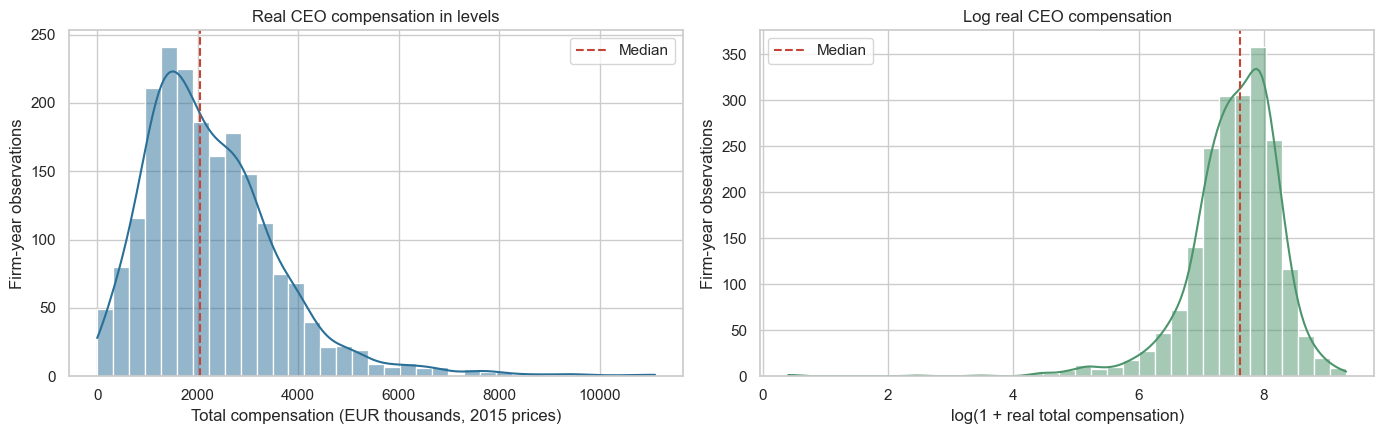

In [595]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

viz_df = df_panel_final.copy()
viz_df = viz_df.replace([np.inf, -np.inf], np.nan)

target_level = "real_totalcompensation_eur_2015"
target_log = "log_real_totalcompensation_eur_2015"
target_plot = viz_df[[target_level, target_log]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(
    data=target_plot,
    x=target_level,
    bins=35,
    kde=True,
    color="#2A6F97",
    ax=axes[0],
)
axes[0].axvline(
    target_plot[target_level].median(),
    color="#C44536",
    linestyle="--",
    label="Median",
)
axes[0].set(
    title="Real CEO compensation in levels",
    xlabel="Total compensation (EUR thousands, 2015 prices)",
    ylabel="Firm-year observations",
)
axes[0].legend()

sns.histplot(
    data=target_plot,
    x=target_log,
    bins=35,
    kde=True,
    color="#4C956C",
    ax=axes[1],
)
axes[1].axvline(
    target_plot[target_log].median(),
    color="#C44536",
    linestyle="--",
    label="Median",
)
axes[1].set(
    title="Log real CEO compensation",
    xlabel="log(1 + real total compensation)",
    ylabel="Firm-year observations",
)
axes[1].legend()

plt.tight_layout()
plt.show()

**Insights:**

- Real total compensation is right-skewed: the median is about **EUR 2.04 million**, the mean is **EUR 2.30 million**, and the 99th percentile is about **EUR 7.44 million**.
    
- The log transformation compresses the high-pay tail and is therefore more suitable as the baseline regression target. A small number of unusually low observations still create a left tail after logging, so later models should report sensitivity to winsorization or explicit minimum-pay filters.

<a id="annual-pay-trend"></a>
### 9.2 Annual Pay Trend and Coverage

The next figure separates the evolution of real pay from the number of usable observations. Mean and median compensation are both shown because their gap reveals whether a small high-pay tail is influencing the annual average.

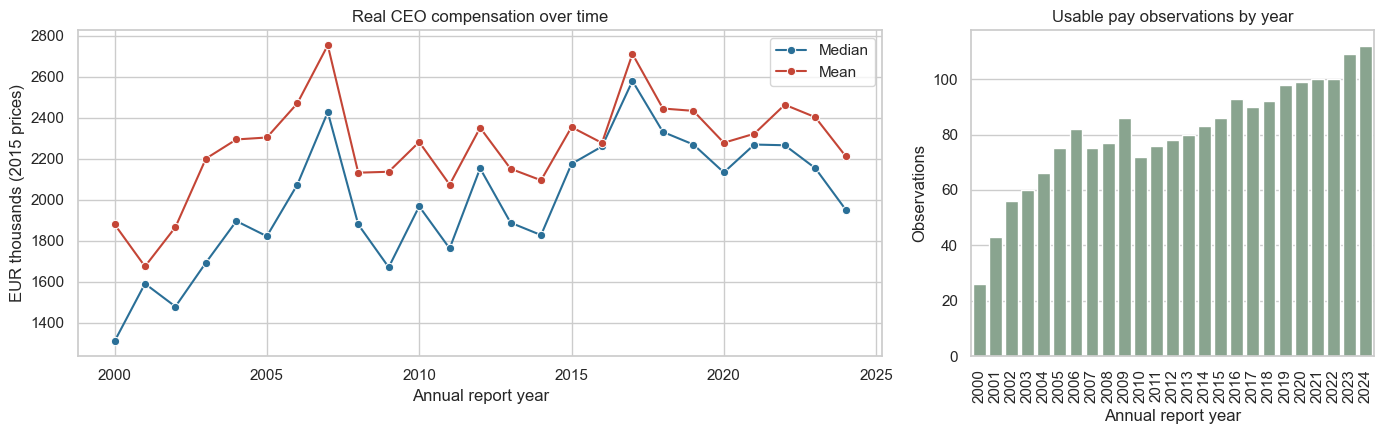

In [596]:
annual_pay = (
    viz_df.dropna(subset=["annualreportyear", target_level])
    .groupby("annualreportyear", as_index=False)
    .agg(
        median_real_pay=(target_level, "median"),
        mean_real_pay=(target_level, "mean"),
        observations=(target_level, "size"),
    )
)

fig, axes = plt.subplots(
    1, 2, figsize=(14, 4.5),
    gridspec_kw={"width_ratios": [2, 1]},
)

sns.lineplot(
    data=annual_pay,
    x="annualreportyear",
    y="median_real_pay",
    marker="o",
    label="Median",
    color="#2A6F97",
    ax=axes[0],
)
sns.lineplot(
    data=annual_pay,
    x="annualreportyear",
    y="mean_real_pay",
    marker="o",
    label="Mean",
    color="#C44536",
    ax=axes[0],
)
axes[0].set(
    title="Real CEO compensation over time",
    xlabel="Annual report year",
    ylabel="EUR thousands (2015 prices)",
)

sns.barplot(
    data=annual_pay,
    x="annualreportyear",
    y="observations",
    color="#84A98C",
    ax=axes[1],
)
axes[1].set(
    title="Usable pay observations by year",
    xlabel="Annual report year",
    ylabel="Observations",
)
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**Insights**

- Median real compensation rises from approximately **EUR 1.31 million in 2000** to a sample peak of **EUR 2.58 million in 2017**, before easing to about **EUR 1.95 million in 2024**.

- The mean is above the median in most years, consistent with the right-skewed target distribution. Coverage also expands from **26 observations in 2000** to **112 in 2024**.

<a id="turnover-event-visualization"></a>
### 9.3 Pay Around CEO Turnover

For treated firms, event time equals zero in the first observed CEO-turnover year. The line shows median real compensation from five years before through five years after that event; the bars show how many firm-years support each point.

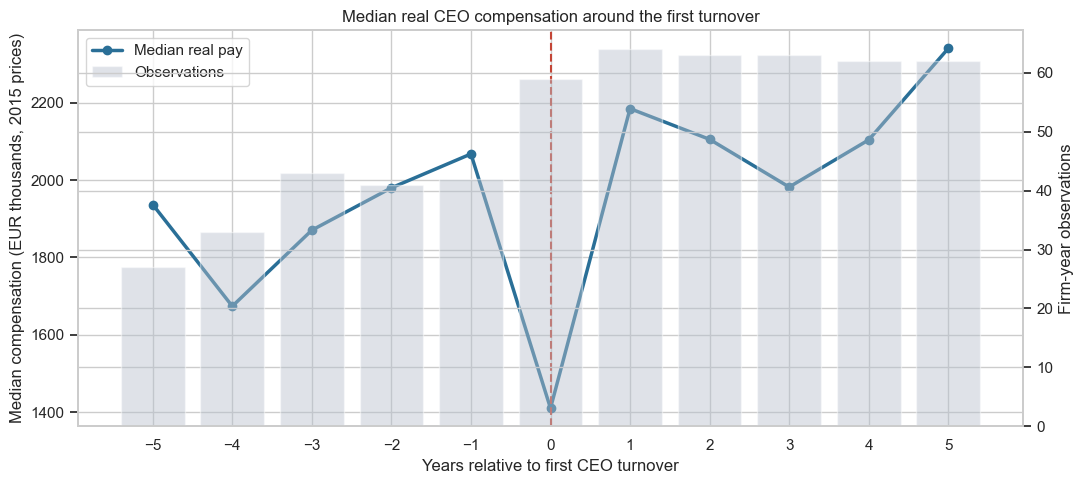

In [597]:
event_pay = (
    viz_df.loc[
        viz_df["treated_firm"].eq(1)
        & viz_df["event_time"].between(-5, 5)
        & viz_df[target_level].notna()
    ]
    .groupby("event_time", as_index=False)
    .agg(
        median_real_pay=(target_level, "median"),
        observations=(target_level, "size"),
    )
)
event_pay["event_time"] = event_pay["event_time"].astype(int)

fig, ax_pay = plt.subplots(figsize=(11, 5))
ax_count = ax_pay.twinx()

ax_count.bar(
    event_pay["event_time"],
    event_pay["observations"],
    color="#B8C0CC",
    alpha=0.45,
    label="Observations",
)
ax_pay.plot(
    event_pay["event_time"],
    event_pay["median_real_pay"],
    color="#2A6F97",
    marker="o",
    linewidth=2.5,
    label="Median real pay",
)
ax_pay.axvline(0, color="#C44536", linestyle="--", linewidth=1.5)
ax_pay.set(
    title="Median real CEO compensation around the first turnover",
    xlabel="Years relative to first CEO turnover",
    ylabel="Median compensation (EUR thousands, 2015 prices)",
)
ax_count.set_ylabel("Firm-year observations")
ax_pay.set_xticks(range(-5, 6))

handles_1, labels_1 = ax_pay.get_legend_handles_labels()
handles_2, labels_2 = ax_count.get_legend_handles_labels()
ax_pay.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

**Insights:**

- Median real compensation falls from about **EUR 2.07 million in event year -1** to **EUR 1.41 million in the turnover year**, then rebounds to approximately **EUR 2.18 million in year +1**.

<a id="exploratory-relationships"></a>
### 9.4 Exploratory Relationships

The correlation heatmap summarizes continuous candidate controls. The sector boxplots use the eight sectors with the most usable pay observations and suppress individual outlier markers so that differences in their central distributions remain visible.

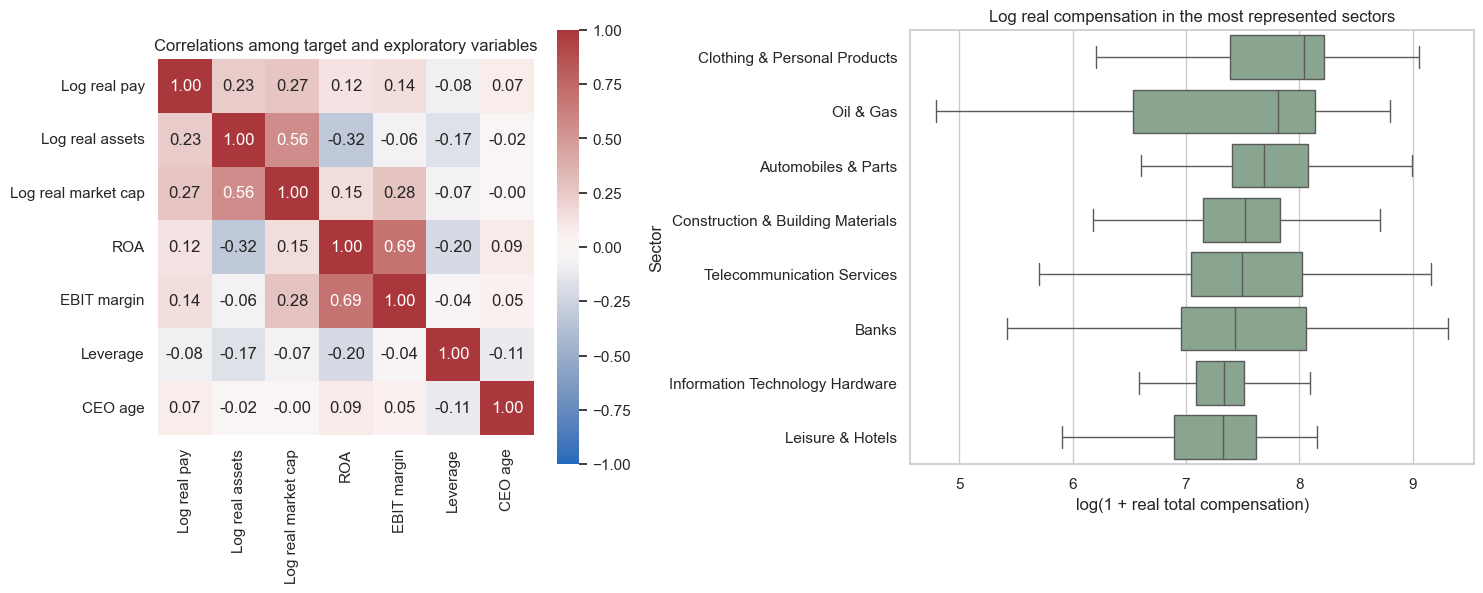

In [598]:
correlation_columns = {
    "log_real_totalcompensation_eur_2015": "Log real pay",
    "log_real_assets_eur_2015": "Log real assets",
    "log_real_market_cap_eur_2015": "Log real market cap",
    "roa": "ROA",
    "ebit_margin": "EBIT margin",
    "leverage": "Leverage",
    "age": "CEO age",
}

corr_data = (
    viz_df[list(correlation_columns)]
    .apply(pd.to_numeric, errors="coerce")
    .rename(columns=correlation_columns)
)

sector_plot = viz_df.dropna(subset=["sector", target_log]).copy()
top_sectors = sector_plot["sector"].value_counts().head(8).index
sector_plot = sector_plot[sector_plot["sector"].isin(top_sectors)]
sector_order = (
    sector_plot.groupby("sector")[target_log]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [1, 1.2]},
)

sns.heatmap(
    corr_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Correlations among target and exploratory variables")

sns.boxplot(
    data=sector_plot,
    x=target_log,
    y="sector",
    order=sector_order,
    color="#84A98C",
    showfliers=False,
    ax=axes[1],
)
axes[1].set(
    title="Log real compensation in the most represented sectors",
    xlabel="log(1 + real total compensation)",
    ylabel="Sector",
)

plt.tight_layout()
plt.show()

**Insights:**

- Log real pay has modest positive correlations with **log market capitalization (0.27)** and **log assets (0.24)**, while its correlations with profitability, leverage, and CEO age are weaker in the pooled sample.

- The stronger correlations between assets and market capitalization (**0.56**) and between ROA and EBIT margin (**0.69**) warn against adding highly related controls without multicollinearity checks.

- Sector distributions also differ visibly—among the most represented sectors, clothing/personal-products and oil-and-gas observations tend to sit above banking, telecommunications, leisure/hotels, and information-technology hardware. These are pooled associations, not estimates of within-firm or causal effects.

- **Modelling implication.** Use log real compensation as the main target, retain firm size and sector as important explanatory dimensions, and estimate turnover effects with firm/year controls rather than reading them directly from the descriptive plots.

<a id="grouped-pay-comparisons"></a>
### 9.5 Mean and Median Pay Across CEO and Firm Groups

Mean and median real CEO compensation are plotted together because their distance is itself informative: a mean materially above the median indicates that a small high-pay tail is pulling up the average. Age and gender include every observed group. To keep labels readable, the industry and headquarters-country panels visualize the **12 groups with the most usable compensation observations**; the complete results remain available in `grouped_ceo_pay_summary`. Each marker is based on firm-year observations, not unique CEOs. The age bands use the BoardEx `age` field retained in the panel; because date of birth is not retained here, this may not equal age in each historical report year.


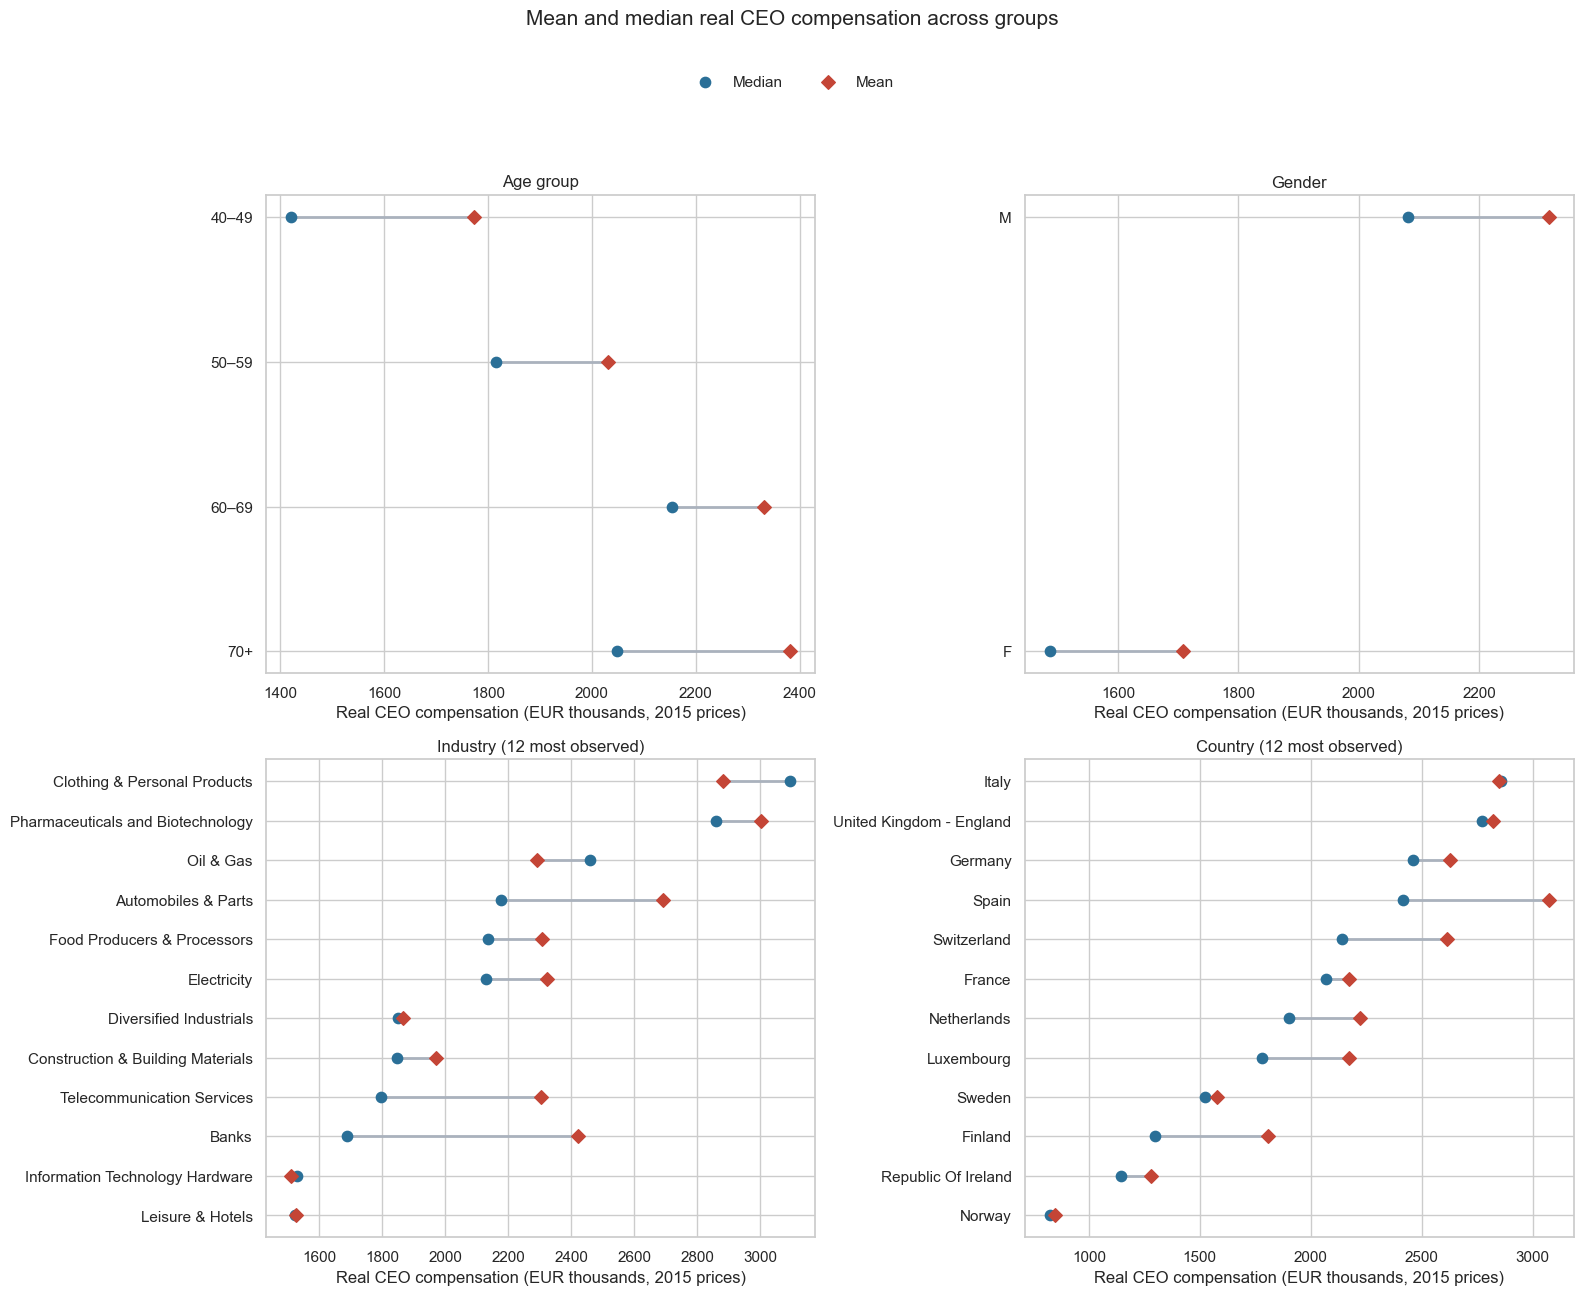

,dimension,group,mean_pay_million_eur,median_pay_million_eur,observations
0,Age group,40–49,1.77,1.42,26
1,Age group,50–59,2.03,1.82,309
2,Age group,60–69,2.33,2.16,887
3,Age group,70+,2.38,2.05,784
4,Gender,F,1.71,1.49,54
5,Gender,M,2.32,2.08,1955
6,Industry,Aerospace & Defence,2.1,2.16,32
7,Industry,Automobiles & Parts,2.69,2.18,94
8,Industry,Banks,2.42,1.69,205
9,Industry,Beverages,2.25,2.11,55


In [599]:
# Construct age bands and harmonize the gender labels used in the grouped summaries.
grouped_viz_df = viz_df.copy()
grouped_viz_df["age_numeric"] = pd.to_numeric(grouped_viz_df["age"], errors="coerce")
grouped_viz_df["age_group"] = pd.cut(
    grouped_viz_df["age_numeric"],
    bins=[0, 39, 49, 59, 69, np.inf],
    labels=["Under 40", "40–49", "50–59", "60–69", "70+"],
)

grouped_viz_df["gender_group"] = (
    grouped_viz_df["gender"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace({"MALE": "M", "FEMALE": "F"})
)

def summarize_grouped_pay(data, group_column, dimension):
    """Return mean, median, and coverage for one grouping variable."""
    summary = (
        data.dropna(subset=[group_column, target_level])
        .groupby(group_column, observed=True)[target_level]
        .agg(mean_pay="mean", median_pay="median", observations="size")
        .reset_index()
        .rename(columns={group_column: "group"})
    )
    summary.insert(0, "dimension", dimension)
    summary["group"] = summary["group"].astype(str)
    return summary

age_pay_summary = summarize_grouped_pay(grouped_viz_df, "age_group", "Age group")
gender_pay_summary = summarize_grouped_pay(grouped_viz_df, "gender_group", "Gender")
industry_pay_summary = summarize_grouped_pay(grouped_viz_df, "sector", "Industry")
country_pay_summary = summarize_grouped_pay(
    grouped_viz_df, "hocountryname", "Headquarters country"
)

grouped_ceo_pay_summary = pd.concat(
    [
        age_pay_summary,
        gender_pay_summary,
        industry_pay_summary,
        country_pay_summary,
    ],
    ignore_index=True,
)

def most_observed(summary, number=12):
    return summary.nlargest(number, "observations").sort_values(
        "median_pay", ascending=True
    )

plot_summaries = {
    "Age group": age_pay_summary.iloc[::-1],
    "Gender": gender_pay_summary.sort_values("median_pay"),
    "Industry (12 most observed)": most_observed(industry_pay_summary),
    "Country (12 most observed)": most_observed(country_pay_summary),
}

def draw_mean_median_dumbbell(ax, summary, title):
    """Plot group medians and means on the same horizontal scale."""
    positions = np.arange(len(summary))
    lower = summary[["mean_pay", "median_pay"]].min(axis=1)
    upper = summary[["mean_pay", "median_pay"]].max(axis=1)

    ax.hlines(
        positions,
        lower,
        upper,
        color="#AAB2BD",
        linewidth=2,
        zorder=1,
    )
    ax.scatter(
        summary["median_pay"],
        positions,
        color="#2A6F97",
        s=55,
        label="Median",
        zorder=2,
    )
    ax.scatter(
        summary["mean_pay"],
        positions,
        color="#C44536",
        marker="D",
        s=48,
        label="Mean",
        zorder=2,
    )
    ax.set_yticks(positions)
    ax.set_yticklabels(summary["group"])
    ax.set_title(title)
    ax.set_xlabel("Real CEO compensation (EUR thousands, 2015 prices)")
    ax.set_ylabel("")

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
for ax, (title, summary) in zip(axes.flat, plot_summaries.items()):
    draw_mean_median_dumbbell(ax, summary, title)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=2,
    frameon=False,
)
fig.suptitle(
    "Mean and median real CEO compensation across groups",
    fontsize=15,
    y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

display(
    grouped_ceo_pay_summary.assign(
        mean_pay_million_eur=lambda x: x["mean_pay"] / 1_000,
        median_pay_million_eur=lambda x: x["median_pay"] / 1_000,
    )[
        [
            "dimension",
            "group",
            "mean_pay_million_eur",
            "median_pay_million_eur",
            "observations",
        ]
    ].round(2)
)


**Insights:**

- Recorded mean pay increases from approximately **EUR 1.77 million for ages 40–49** to **EUR 2.38 million for ages 70+**, although the 40–49 group contains only **26 firm-years**.

- Female CEO observations have mean/median pay of approximately **EUR 1.71/1.49 million**, compared with **EUR 2.31/2.08 million** for male observations; this comparison is highly unbalanced (**54 versus 1,960 firm-years**) and is not an adjusted gender pay gap.

- Among the 12 most represented industries, median pay ranges from roughly **EUR 1.52 million** in leisure/hotels to **EUR 3.10 million** in clothing/personal products. Across the displayed countries, it ranges from about **EUR 0.82 million** in Norway to **EUR 2.86 million** in Italy.

- The gaps between paired markers also reveal within-group skewness—for example, banking and Finland have means substantially above their medians. All comparisons are pooled and descriptive: they combine firm size, sector, country, year, and repeated CEO observations. Formal age, gender, industry, or country effects therefore require multivariate modelling and appropriate firm/year controls.


<a id="final-data-preprocessing"></a>
## 10. Final Data Preprocessing


### 10.1 Handling Missing Values

In [ ]:
df_final_eur = df_panel_final[
    [
        # Panel identifiers
        "companyid",
        "isin",
        "annualreportyear",
        "annualreportdate",

        # Individual demographics
        "directorid",
        "directorname_emp",
        "gender",
        "age",

        # CEO turnover / event-study variables
        "ceo_turnover_dummy",
        "treated_firm",
        "event_time",
        "post_turnover",
        "event_window_3yr",
        "event_window_5yr",

        # CEO compensation outcome
        "log_real_totalcompensation_eur_2015",

        # Company information
        "companyname",
        "sector",
        "hocountryname",
        "emp",

        # Firm size
        "log_real_assets_eur_2015",

        # Company performance controls
        "roa",
        "log_real_market_cap_eur_2015",
        "leverage",
    ]
].copy()

df_final_eur

,companyid,isin,annualreportyear,annualreportdate,directorid,directorname_emp,gender,age,ceo_turnover_dummy,treated_firm,event_time,post_turnover,event_window_3yr,event_window_5yr,log_real_totalcompensation_eur_2015,companyname,sector,hocountryname,emp,log_real_assets_eur_2015,roa,log_real_market_cap_eur_2015,leverage
0,422.0,CH0012221716,2001,2001-12-01,14884.0,Jörgen Centerman,M,77,0,1,-1.0,0,1,1,7.657364,ABB LTD,Engineering & Machinery,Switzerland,156.865,10.558117,-0.004019,<NA>,0.155918
1,422.0,CH0012221716,2002,2002-12-01,11152.0,Juergen Dormann,M,86,1,1,0.0,1,1,1,7.367959,ABB LTD,Engineering & Machinery,Switzerland,139.051,10.296252,0.003284,<NA>,0.182034
2,422.0,CH0012221716,2003,2003-12-01,11152.0,Juergen Dormann,M,86,0,1,1.0,1,1,1,7.712021,ABB LTD,Engineering & Machinery,Switzerland,116.464,10.135749,0.002828,<NA>,0.206819
3,422.0,CH0012221716,2004,2004-12-01,11152.0,Juergen Dormann,M,86,0,1,2.0,1,1,1,7.946564,ABB LTD,Engineering & Machinery,Switzerland,102.537,9.844118,0.018155,<NA>,0.198606
4,422.0,CH0012221716,2005,2005-12-01,4611.0,Fred Kindle,M,67,1,1,3.0,1,1,1,6.977566,ABB LTD,Engineering & Machinery,Switzerland,103.5,9.871334,0.039639,<NA>,0.176558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2064,2794683.0,DE000SHL1006,2022,2022-09-01,831291.0,Doctor Bernd Montag,M,56,0,0,NaN,0,0,0,7.635883,SIEMENS HEALTHINEERS AG,Health,Germany,69.5,10.651183,0.041544,10.588404,0.281535
2065,2794683.0,DE000SHL1006,2023,2023-09-01,831291.0,Doctor Bernd Montag,M,56,0,0,NaN,0,0,0,7.712263,SIEMENS HEALTHINEERS AG,Health,Germany,71.0,10.543859,0.032324,10.603393,0.262574
2066,2794683.0,DE000SHL1006,2024,2024-09-01,831291.0,Doctor Bernd Montag,M,56,0,0,NaN,0,0,0,7.792641,SIEMENS HEALTHINEERS AG,Health,Germany,72.0,10.507979,0.042167,10.773278,0.292151
2067,3081662.0,NL0013654783,2025,2025-03-01,1045804.0,Fabricio Rocha,M,49,0,1,1.0,1,1,1,<NA>,PROSUS NV (Myriad International Holdings NV pr...,Speciality & Other Finance,Netherlands,<NA>,<NA>,<NA>,<NA>,<NA>


In [622]:
summarize_dataframe(df_final_eur)

### Dataset overview


,value
rows,2069
columns,23
duplicate rows,0
memory usage,1.24 MB


### Column coverage and dtypes


,dtype,non_null,missing,missing_pct,unique
log_real_market_cap_eur_2015,Float64,1638,431,20.83,1638
roa,Float64,1908,161,7.78,1908
emp,Float64,1965,104,5.03,1902
log_real_assets_eur_2015,Float64,2001,68,3.29,2001
leverage,Float64,2001,68,3.29,1978
event_time,float64,2009,60,2.90,70
log_real_totalcompensation_eur_2015,Float64,2014,55,2.66,2007
age,string,2060,9,0.43,46
gender,string,2064,5,0.24,2
directorid,Float64,2069,0,0.00,351


### Numeric columns


,count,mean,std,min,25%,50%,75%,max
companyid,2069.0,115450.654906,422423.928376,422.0,9074.0,17619.0,27916.0,3486568.0
annualreportyear,2069.0,2013.511358,7.169642,1997.0,2008.0,2014.0,2020.0,2025.0
directorid,2069.0,350503.301112,464194.83463,334.0,14700.0,35372.0,532652.0,2703829.0
ceo_turnover_dummy,2069.0,0.120348,0.325447,0.0,0.0,0.0,0.0,1.0
treated_firm,2069.0,0.971,0.167846,0.0,1.0,1.0,1.0,1.0
event_time,2009.0,10.749129,11.143432,-23.0,3.0,10.0,18.0,47.0
post_turnover,2069.0,0.823586,0.381264,0.0,1.0,1.0,1.0,1.0
event_window_3yr,2069.0,0.18608,0.389265,0.0,0.0,0.0,0.0,1.0
event_window_5yr,2069.0,0.277429,0.447838,0.0,0.0,0.0,1.0,1.0
log_real_totalcompensation_eur_2015,2014.0,7.535211,0.730727,0.403827,7.187494,7.620514,7.997727,9.314701


### Categorical columns


,count,missing,unique,top,top_frequency
column,,,,,
isin,2069,0,138,SE0000115446,27
directorname_emp,2069,0,350,Michael O'Leary,26
gender,2064,5,2,M,2009
age,2060,9,46,71,124
companyname,2069,0,138,VOLVO AB,27
sector,2069,0,32,Banks,209
hocountryname,2069,0,15,France,692


### Datetime columns


,min,max,missing
annualreportdate,1997-12-01,2025-12-01,0


{'overview':                   value
 rows               2069
 columns              23
 duplicate rows        0
 memory usage    1.24 MB,
 'missing':                                               dtype  non_null  missing  \
 log_real_market_cap_eur_2015                Float64      1638      431   
 roa                                         Float64      1908      161   
 emp                                         Float64      1965      104   
 log_real_assets_eur_2015                    Float64      2001       68   
 leverage                                    Float64      2001       68   
 event_time                                  float64      2009       60   
 log_real_totalcompensation_eur_2015         Float64      2014       55   
 age                                          string      2060        9   
 gender                                       string      2064        5   
 directorid                                  Float64      2069        0   
 directorname_emp         

---

<a id="planned-methods"></a>
## 10. Planned Methods


The completed preparation pipeline produces `df_panel_final` with raw values, nominal EUR values, and real 2015 EUR values. Modelling should use `log_real_totalcompensation_eur_2015` as the baseline pay outcome and `log_real_assets_eur_2015` or `log_real_market_cap_eur_2015` as size controls. The next stage applies one method from each course block, with a shared emphasis on transparent preprocessing and robustness evaluation.

### 10.1 Causal Inference
- [X] Causal graph / DAG (DoWhy)
- [X] Backdoor adjustment
- [ ] Instrumental variable
- [ ] Propensity score stratification
- [ ] Other: ___

*Justification:* We will model CEO turnover as a governance shock in a DAG and use backdoor adjustment to control for firm fundamentals that affect both turnover and pay. We will estimate the causal effect of turnover using pre/post (event‑study style) comparisons around the turnover year.

### 10.2 Supervised Learning
- [X] Linear / Ridge / Lasso regression
- [X] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [X] Decision Tree / Random Forest
- [X] Gradient Boosting (XGBoost / LightGBM / sklearn GBM)
- [ ] Neural network (regression or classification)
- [ ] Other: ___

*Justification:* Supervised models will benchmark expected compensation conditional on firm and executive characteristics. Linear models provide interpretable baselines and covariate effects, while tree-based and boosting models capture nonlinearities/interactions for more accurate counterfactual pay predictions. We will use Optuna to tune boosting hyperparameters (e.g., depth, learning rate, subsampling) to avoid overfitting and compare against simpler baselines.

### 10.3 Unsupervised Learning / Generative Models
- [X] K-Means clustering
- [ ] Hierarchical clustering
- [X] Variational autoencoder
- [ ] GAN
- [ ] Other: ___

*Justification:* Clustering will segment firms into comparable peer groups before causal estimation and highlight heterogeneous effects across turnover regimes. A VAE will learn low-dimensional representations of firm/executive profiles to detect anomalous pay structures and support exploratory subgroup analysis.

<a id="evaluation-strategy"></a>
## 11. Evaluation Strategy


The mission succeeds if the final notebook produces a transparent, reproducible panel and uses it to answer the research question from three angles:

- **Causal inference:** estimate whether CEO turnover is associated with changes in real 2015 EUR CEO pay after adjusting for firm characteristics.
- **Prediction:** benchmark models of real 2015 EUR compensation using RMSE/MAE and classification metrics where turnover or high-pay outcomes are modeled.
- **Unsupervised learning:** identify firm or executive clusters that reveal heterogeneous compensation patterns.
- **Robustness:** report missing-data coverage, sensitivity to winsorization, and whether results change across event windows.


<a id="work-plan"></a>
## 12. Work Plan


| Step | Owner | Description | Output | Status |
|---:|---|---|---|---|
| 1 | Achmad | Define the STOXX 600 universe and retrieve BoardEx/Compustat inputs | Raw source tables | Complete |
| 2 | Kajetan | Clean identifiers, dates, compensation variables, and missing values | Harmonized source tables | Complete |
| 3 | Achmad | Identify firm-level CEO spells and turnover events | `ceo_turnover_firm_year` | Complete |
| 4 | Kajetan | Match CEO remuneration to valid CEO spells | `ceo_pay_panel` | Complete |
| 5 | Achmad | Convert monetary inputs to EUR; add market capitalization and financial ratios | Nominal-EUR source tables and `df_funda` | Complete |
| 6 | Achmad + Kajetan | Merge inputs, apply CPI, and validate firm-year uniqueness | Real-2015-EUR `df_panel_final` | Complete |
| 7 | Kajetan | Implement causal and event-window analysis | Estimates and robustness checks | Complete |
| 8 | Achmad | Implement supervised and unsupervised learning | Model metrics, clusters, and heterogeneity | Planned |
| 9 | Achmad + Kajetan | Synthesize findings and limitations | Final discussion and conclusion | Planned |


### 13.2 Supervised Learning

In [600]:
# Supervised learning analysis

### 13.3 Unsupervised / Generative Learning

In [601]:
# Unsupervised / generative analysis

### 13.4 Discussion & Conclusion *(complete for final submission)*


*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*
